# Deep Learning Volatility: a reproduction with our own code

Horvath, Muguruza, Tomas, *Deep learning volatility: a deep neural network perspective on pricing and calibration in (rough) volatility models*, Quantitative Finance 21(1), 2021 (arXiv:1901.09647v2). Figure, table, section and page numbers below refer to the arXiv v2 PDF.

Sections 1 to 4: the paper, the data and our code, checked end to end on a small subset (a few minutes on a laptop CPU; those numbers are **not results**). Section 5: the results of the full runs, rebuilt from the files in `results/` that `python -m src.run_all --full` produced; the test set was read once, by `src/final_eval.py`, after the code, the settings and the trained networks were frozen. Section 6: conclusions, with every number read from those files.

Repository: [zavaz5/deep-learning-volatility](https://github.com/zavaz5/deep-learning-volatility). Every step here is also a command line; `README.md` lists them.

In [1]:
import inspect, json, os, subprocess, sys, time
from pathlib import Path
import numpy as np, pandas as pd
from IPython.display import Image, Markdown, display

REPO = "https://github.com/zavaz5/deep-learning-volatility"
if not Path("src/config.py").exists():
    subprocess.run(["git", "clone", "--depth", "1", REPO], check=True)
    os.chdir(REPO.rstrip("/").split("/")[-1])
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
sys.path.insert(0, os.getcwd())

def run(command: str) -> float:
    start = time.perf_counter()
    done = subprocess.run([sys.executable, *command.split()[1:]], capture_output=True, text=True)
    seconds = time.perf_counter() - start
    tail = "\n".join((done.stdout + done.stderr).strip().splitlines()[-2:])
    print(f"$ {command}   [{seconds:.1f} s]\n{tail}\n")
    if done.returncode:
        raise RuntimeError(f"failed: {command}")
    return seconds

run("python data/get_data.py")
from src.config import CALIBRATION, DATASETS, MATURITIES, QUICK, RECIPE, SEEDS, SPLIT, STRIKES
from src.ledger import us_to_ms
from src.paper_numbers import NOTEBOOK, PAPER
import torch
pd.set_option("display.width", 160); pd.set_option("display.max_colwidth", 80)
runtimes = pd.read_csv("results/runtimes_full.csv")
print(f"torch {torch.__version__}, CPU only, float64 | full run recorded in results/runtimes_full.csv: "
      f"{len(runtimes)} steps, {runtimes.seconds.sum() / 60:.0f} minutes on {json.load(open('results/environment.json'))['cpu']}")

$ python data/get_data.py   [0.1 s]
ok (already present)  NNParametersr1FactorTermStructure.txt
ok (already present)  SurfacesFromNN1FactorTermStructure.txt



torch 2.14.0, CPU only, float64 | full run recorded in results/runtimes_full.csv: 25 steps, 38 minutes on Apple M5 Pro


## 1. The paper and the task

Calibrating a rough volatility model means finding the parameters whose implied-volatility surface matches the market's. Rough Bergomi has no closed-form or PDE price: variance depends on the whole past path, so every surface costs a Monte Carlo run, and calibration needs hundreds of them. The paper's idea is a two-step scheme: **offline**, learn the map from parameters to the surface once with a small neural network trained on Monte Carlo data; **online**, run an ordinary least-squares optimizer on the network, which evaluates in a small fraction of a millisecond and has an exact gradient.

The surface is treated as an image on a fixed grid of 8 maturities × 11 strikes, 88 numbers. The 11 model parameters are eight forward variances $\xi_1 \dots \xi_8$ (one per maturity bucket), the volatility of volatility $\nu$, the spot–vol correlation $\rho$ and the Hurst parameter $H$. Two objectives (paper, Section 3.1.1):

$$\hat w = \underset{w}{\operatorname{argmin}} \sum_{u=1}^{N} \sum_{i,j} \big( F(\theta_u, w)_{ij} - F^{*}(\theta_u)_{ij} \big)^2
\qquad\qquad
\hat\theta = \underset{\theta \in \Theta}{\operatorname{argmin}} \sum_{i,j} \big( \tilde F(\theta)_{ij} - \sigma^{\mathrm{MKT}}(T_i, k_j) \big)^2$$

Left, training: $F(\cdot, w)$ is the network, $F^{*}$ the Monte Carlo surface, $u$ runs over training samples. Right, calibration: $\tilde F = F(\cdot, \hat w)$ is the trained network and the optimizer runs over the parameter box $\Theta$.

**What we reproduce, with our own PyTorch and NumPy code on the authors' published data:** Figures 6 and 7 (error heatmaps), the network columns of Table 2 (speed), Figure 8 (calibration time of seven optimizers) and Figures 9 and 10 (calibration accuracy), for rough Bergomi and for 1-factor Bergomi. **Not reproduced:** the Monte Carlo column of Table 2 and Figures 4 and 5 (no simulator is published), the SPX calibration (no public option data), barrier options (no data, no pricer) and the Figure 14 classifier (a stretch goal we did not take).

## 2. The data

Two files from the authors' repository, one per model: 80,000 rows of 11 parameters and 88 implied vols, produced by their Monte Carlo pricer. They are included in `data/` with the authors' MIT licence (`data/LICENSE`), and `data/get_data.py` checks their SHA-256; `src/data.py` asserts the facts below when it loads them, reproduces the authors' train/test split exactly (so our 12,000 test rows are theirs, in their order), carves 8,000 validation rows out of their 68,000 training rows with a fixed seed, and fits the scalers on the remaining 60,000 training rows only. **The locked test set:** the test rows are read by one script, `src/final_eval.py`, once; this notebook never loads them.

rough Bergomi file: shape (80000, 99), float64, NaN or inf: 0; grid: maturities [0.1, 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.0], strikes [0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5]
split: {'train_idx': 60000, 'val_idx': 8000, 'test_idx': 12000} (train / validation / test); the paper says the rho range is (-0.95, -0.1), the file spans -1 to -2.33e-05 (table of section 5, row 2)


,parameter,file min,file max,training box (src/config.py)
0,xi1,0.0100,0.16,"[0.01, 0.16]"
1,xi2,0.0100,0.16,"[0.01, 0.16]"
2,xi3,0.0100,0.16,"[0.01, 0.16]"
3,xi4,0.0100,0.16,"[0.01, 0.16]"
4,xi5,0.0100,0.16,"[0.01, 0.16]"
5,xi6,0.0100,0.16,"[0.01, 0.16]"
6,xi7,0.0100,0.16,"[0.01, 0.16]"
7,xi8,0.0100,0.16,"[0.01, 0.16]"
8,nu,0.5001,4.00,"[0.5, 4]"
9,rho,-1.0000,-0.00,"[-1, 0]"


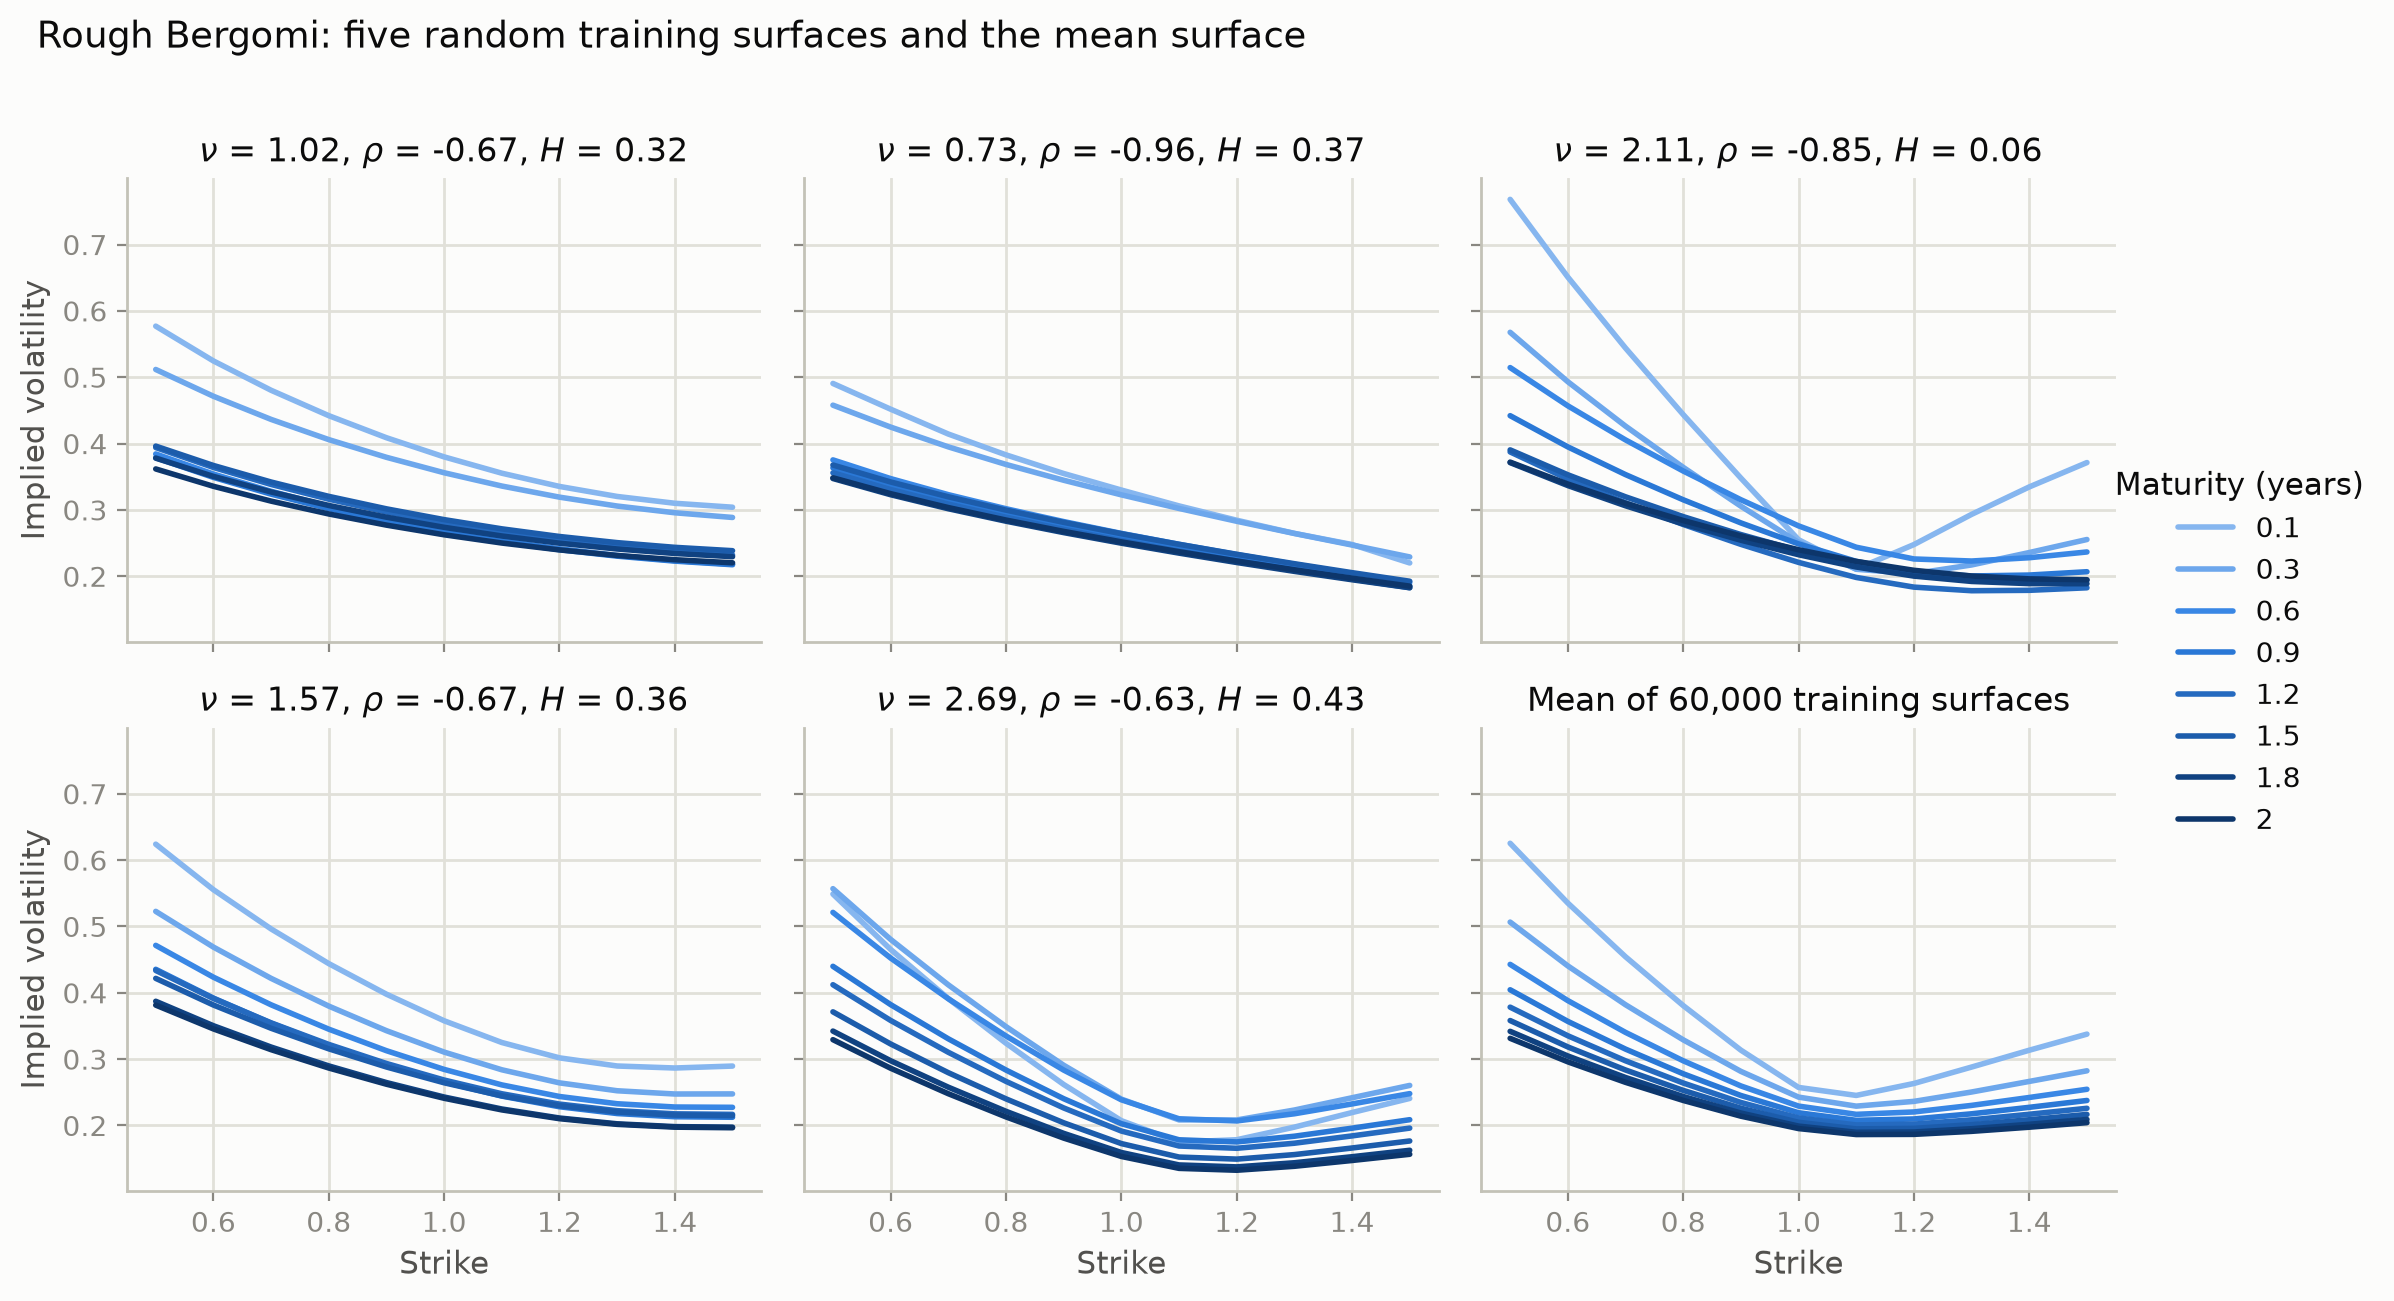

In [2]:
facts = json.load(open("results/rbergomi/data_facts.json"))
box = pd.DataFrame({"parameter": facts["param_names"], "file min": facts["param_min"], "file max": facts["param_max"],
                    "training box (src/config.py)": [f"[{lo:g}, {hi:g}]" for lo, hi in zip(DATASETS["rbergomi"]["lower"], DATASETS["rbergomi"]["upper"])]})
print(f"rough Bergomi file: shape {tuple(facts['shape'])}, {facts['dtype']}, NaN or inf: {facts['n_nan_or_inf']}; "
      f"grid: maturities {MATURITIES}, strikes {STRIKES}")
print(f"split: {facts['split_sizes']} (train / validation / test); the paper says the rho range is {PAPER['rho_range'][0]}, the file spans "
      f"{facts['param_min'][9]:.3g} to {facts['param_max'][9]:.3g} (table of section 5, row 2)")
display(box.round(4))
display(Image("results/figures/rbergomi/surfaces.png", width=900))

The figure above is our first sanity check (five random training surfaces and the mean surface): short maturities show the steepest smiles, so the 88 numbers were reshaped the right way round.

## 3. Our implementation

Everything lives in `src/` and is imported here, so the notebook shows the code that produced the results rather than a copy of it.

- `src/model.py`: the network, 11 → 30 → 30 → 30 → 30 → 88 with ELU, in float64, with the Keras initialisation the authors used. It has **5,878** weights; the paper's text says 6,808 because its formula counts one hidden-to-hidden map too many (table of section 5, row 1).
- `src/train.py`: Adam, batch 32, RMSE loss on scaled outputs, patience 25, up to 500 epochs, best validation weights restored. The authors stop on the test set and keep the last epoch.
- `src/calibrate.py`: the network in plain NumPy, its exact 88 × 11 Jacobian by the chain rule, and eight optimizer settings (the paper's seven, plus the authors' actual `least_squares` call, whose default method is not Levenberg-Marquardt).

In [3]:
from src.model import build_network, count_weights, numpy_weights
from src.calibrate import forward, jacobian, GRADIENT_BASED, GRADIENT_FREE
print(inspect.getsource(build_network))
net = build_network()
print(f"trainable weights: {count_weights(net):,} (paper's text: {PAPER['n_weights_stated'][0]:,}; authors' model summary: {NOTEBOOK['rbergomi']['n_weights'][0]:,})")

def build_network(activation: str = "elu") -> nn.Sequential:
    """Create the network with the authors' initialisation.

    Keras initialises a Dense layer with Glorot-uniform weights and zero biases. PyTorch's own
    default is different, so we set the Keras scheme explicitly; then the framework and the random
    seed are the only differences between our training run and theirs.
    `activation` exists for the ELU-versus-ReLU ablation; the reproduction always uses "elu".
    """
    make_activation = {"elu": nn.ELU, "relu": nn.ReLU}[activation]
    sizes = [N_PARAMS] + [RECIPE["width"]] * RECIPE["n_hidden_layers"]
    layers = []
    for n_in, n_out in zip(sizes[:-1], sizes[1:]):
        layers += [nn.Linear(n_in, n_out, dtype=torch.float64), make_activation()]
    layers.append(nn.Linear(sizes[-1], N_VOLS, dtype=torch.float64))
    net = nn.Sequential(*layers)
    for layer in net:
        if isinstance(layer, nn.Linear):
            nn.init.xavier_uniform_(layer.weight)
        

In [4]:
print(inspect.getsource(forward)); print(inspect.getsource(jacobian))
torch.manual_seed(1); net = build_network()
with torch.no_grad():
    for p in net.parameters(): p.add_(0.5 * torch.randn_like(p))
weights, worst_f, worst_j = numpy_weights(net), 0.0, 0.0
for x in np.random.default_rng(1).uniform(-1, 1, size=(25, 11)):
    with torch.no_grad(): worst_f = max(worst_f, np.abs(forward(weights, x) - net(torch.from_numpy(x)).numpy()).max())
    worst_j = max(worst_j, np.abs(jacobian(weights, x) - torch.autograd.functional.jacobian(net, torch.from_numpy(x)).numpy()).max())
print(f"largest gap over 25 random inputs: forward pass {worst_f:.1e}, Jacobian (88 x 11) {worst_j:.1e}")
print("optimizers:", list(GRADIENT_BASED), "+", list(GRADIENT_FREE))
print("calibration settings:", {k: v for k, v in CALIBRATION.items()})

def forward(weights: Weights, x: np.ndarray) -> np.ndarray:
    """Network output for one scaled parameter vector (11,) or a batch (n, 11)."""
    a = x
    for W, b in weights[:-1]:
        a = elu(a @ W.T + b)
    W, b = weights[-1]
    return a @ W.T + b

def jacobian(weights: Weights, x: np.ndarray) -> np.ndarray:
    """Exact 88 x 11 matrix of d output_i / d x_j at one scaled parameter vector, by the chain rule.

    Each hidden layer maps a -> elu(W a + b), whose derivative is diag(elu'(z)) W. Multiplying
    these layer by layer, starting from the identity, gives the derivative of the whole network.
    """
    a, J = x, np.eye(len(x))
    for W, b in weights[:-1]:
        z = W @ a + b
        J = elu_prime(z)[:, None] * (W @ J)
        a = elu(z)
    return weights[-1][0] @ J

largest gap over 25 random inputs: forward pass 0.0e+00, Jacobian (88 x 11) 4.3e-14
optimizers: ['L-BFGS-B', 'SLSQP', 'BFGS', 'Levenberg-Marquardt', 'least_squares default (TRF)'] + ['COBYLA', 'Different

## 4. End-to-end check on a subset (not results)

`--quick` runs every script on 1,600 training and 400 validation rows, 5 epochs and 20 calibrations, and writes only under `results/quick/`. The final-evaluation script runs in `--dry-run` mode, which substitutes validation rows for test rows; the test set stays untouched. The commands are the ones `README.md` lists.

In [5]:
steps = ["python -m src.data --model rbergomi --quick", "python -m src.train --model rbergomi --seed 0 --quick",
         "python -m src.evaluate --model rbergomi --quick", "python -m src.speed --model rbergomi --quick",
         "python -m src.calibrate --model rbergomi --quick", "python -m src.plots --model rbergomi --figure all --quick"]
steps += [f"python -m src.experiments.{name} --model rbergomi --quick" for name in ("seeds", "edge_of_box", "worst_errors", "offline_cost", "sample_efficiency", "baselines")]
steps += ["python -m src.final_eval --model rbergomi --quick --dry-run"]
timed = pd.DataFrame({"command": steps, "seconds": [run(s) for s in steps]})
print(f"{len(steps)} steps in {timed.seconds.sum() / 60:.1f} minutes")

$ python -m src.data --model rbergomi --quick   [0.8 s]
rbergomi: checks passed, split {'train_idx': 60000, 'val_idx': 8000, 'test_idx': 12000}, scalers fitted on 1600 training rows



$ python -m src.train --model rbergomi --seed 0 --quick   [1.8 s]
  "seconds": 0.07304662489332259
}



$ python -m src.evaluate --model rbergomi --quick   [1.2 s]
    0 train    1600             5.4229                10.5293                  2.3960               12.0635           123.9730            17.0711            32.2601                     0.8421
    0   val     400             5.3009                10.0964                  2.3046               12.7417            92.4675            16.0542            31.5937                     0.8437



$ python -m src.speed --model rbergomi --quick   [3.5 s]
         numpy_jacobian      25.73       25.07       27.73    26.06    0.95        7              1000
torch_autograd_jacobian    3212.62     3152.91     3250.04  3208.58   26.87        7                50



$ python -m src.calibrate --model rbergomi --quick   [13.2 s]
     Differential Evolution           3  295.512    289.144  259.811  335.670         13081.000          1.000         1.000            1.552         1.608         1.613         1.614
                Nelder-Mead           3  116.449    116.793  115.616  117.042          6750.333          0.000         1.000            1.552         1.605         1.610         1.611



...

$ python -m src.experiments.worst_errors --model rbergomi --quick   [1.6 s]
parameter_grid     H      0.025       0.084     nu       2.688        3.125       5            35.132                       1.0             1       NaN     NaN                      NaN
parameter_grid     H      0.025       0.084     nu       3.125        3.562       4            34.615                       1.0             0       NaN     NaN                      NaN



$ python -m src.experiments.offline_cost --model rbergomi --quick   [0.9 s]
    network_ms_per_calibration     0.973           ms                               ours, calibration_summary_val.csv
       break_even_calibrations   303.033 calibrations                       offline cost / time saved per calibration



$ python -m src.experiments.sample_efficiency --model rbergomi --quick   [3.7 s]
     800     0             7.3982           206.4114           5         0.0474
    1600     0             5.3009            92.4675           5         0.0750



$ python -m src.experiments.baselines --model rbergomi --quick   [6.3 s]
         k-nearest neighbours                         k = 10, distance weights     1600        0.000              7.778             52.334            129.537                       6.914            252.666         247.646         260.912
            Gradient boosting 20 rounds, learning rate 0.1, one model per cell     1600        2.350              5.619             29.798             94.627                       6.034          76090.854       71974.116       81150.454



$ python -m src.final_eval --model rbergomi --quick --dry-run   [19.0 s]
  Gradient boosting: 20 rounds, learning rate 0.1, one model per cell: validation error 5.619%, fit 2.3 s
wrote /private/var/folders/xp/mcnf1br52v92r_cvv8pf58_r0000gn/T/tmp.rorKJsXLmu/publish/results/quick/figures/rbergomi/baselines_dryrun.png

13 steps in 0.9 minutes


subset network, seed 0 (5 epochs on 1,600 rows: a smoke test, not a result):


,split,n_rows,avg_rel_error_pct,max_rel_error_pct
0,train,1600,5.423,123.973
1,val,400,5.301,92.468


,optimizer,n_surfaces,mean_ms,share_in_box,rmse_q99_pct
0,L-BFGS-B,20,4.543,1.000,1.759
1,SLSQP,20,1.832,1.000,1.759
2,BFGS,20,5.808,0.050,1.657
3,Levenberg-Marquardt,20,0.973,0.050,1.657
4,least_squares default (TRF),20,1.561,0.050,1.657
5,COBYLA,3,3475.552,0.667,1.613
6,Differential Evolution,3,295.512,1.000,1.613
7,Nelder-Mead,3,116.449,1.000,1.610


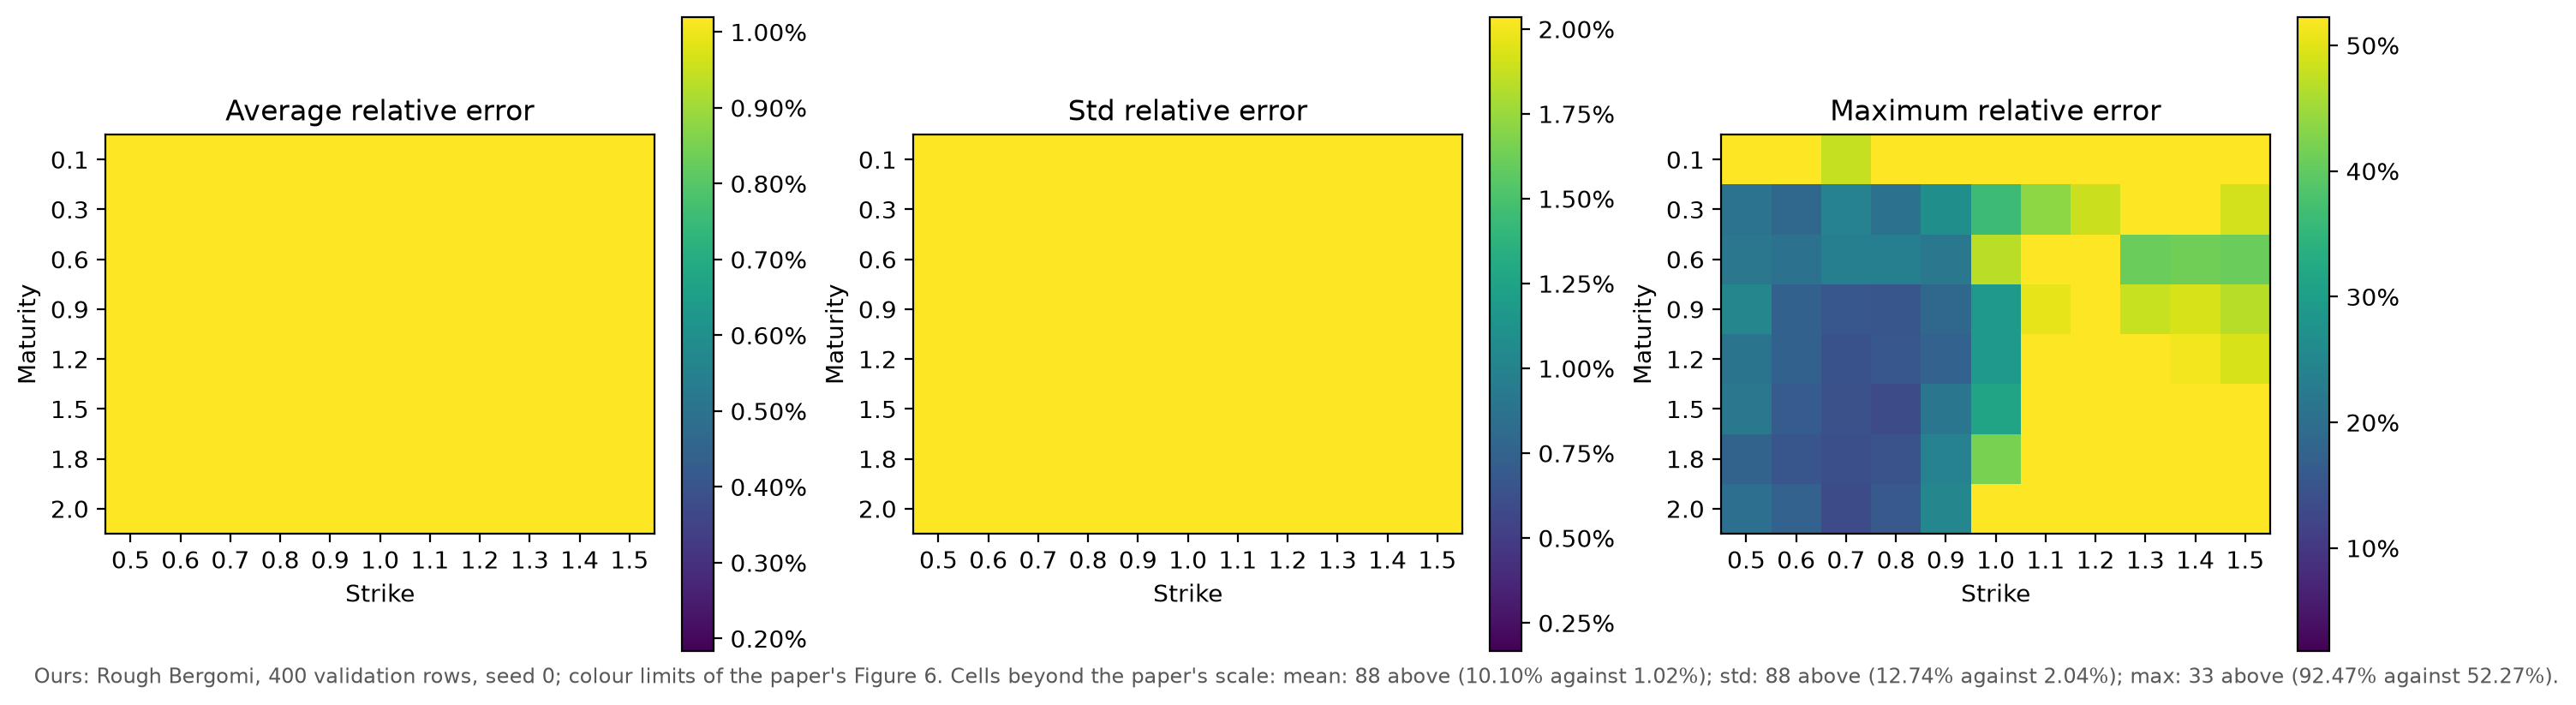

In [6]:
quick = pd.read_csv("results/quick/rbergomi/accuracy_summary.csv")
print("subset network, seed 0 (5 epochs on 1,600 rows: a smoke test, not a result):")
display(quick[["split", "n_rows", "avg_rel_error_pct", "max_rel_error_pct"]].round(3))
display(pd.read_csv("results/quick/rbergomi/calibration_summary_val.csv")[["optimizer", "n_surfaces", "mean_ms", "share_in_box", "rmse_q99_pct"]].round(3))
display(Image("results/quick/figures/rbergomi/error_heatmaps_val.png", width=900))

## 5. Results of the full runs

Everything below is read from `results/`: the outputs of `python -m src.run_all --full` (five seeds per model, 5,000 calibrated test surfaces, every experiment) and of the single run of `src/final_eval.py`, made after the code and the networks were frozen. Numbers quoted from the paper come from `src/paper_numbers.py`, where each is typed once with its page, table or figure. The **Origin** of every result is marked: *reproduction* of something the paper reports, or one of *our upgrades*, *our critique evidence* and *our stretch experiments*, which the paper does not contain.

### Table A. Accuracy against the paper (Figures 6 and 7) — reproduction

paper  ours (test set)
model            quantity                                                                                                
Rough Bergomi    average relative error, 5 seeds                                          far below 0.5%  0.459% ± 0.012%
                 largest cell average, seed 0                              1.02% (top of the colour bar)            1.14%
                 largest cell standard deviation, seed 0                                           2.04%            2.14%
                 maximum relative error, seed 0                 25% in the text; 52.3% on the colour bar            58.0%
                 share of cells above the 1% bid-ask yardstick                              not reported             9.8%
1-factor Bergomi average relative error, 5 seeds                                          far below 0.5%  0.290% ± 0.009%
                 largest cell average, seed 0                              0.65% (top of the colour bar)            0.68%
                 largest cell standard deviation, seed 0                                           0.85%            0.99%
                 maximum relative error, seed 0                 25% in the text; 17.3% on the colour bar            15.4%
                 share of cells above the 1% bid-ask yardstick                              not reported             4.1%

Our heatmaps, drawn with the paper's layout and colour limits; open the paper's Figure 6 beside them:


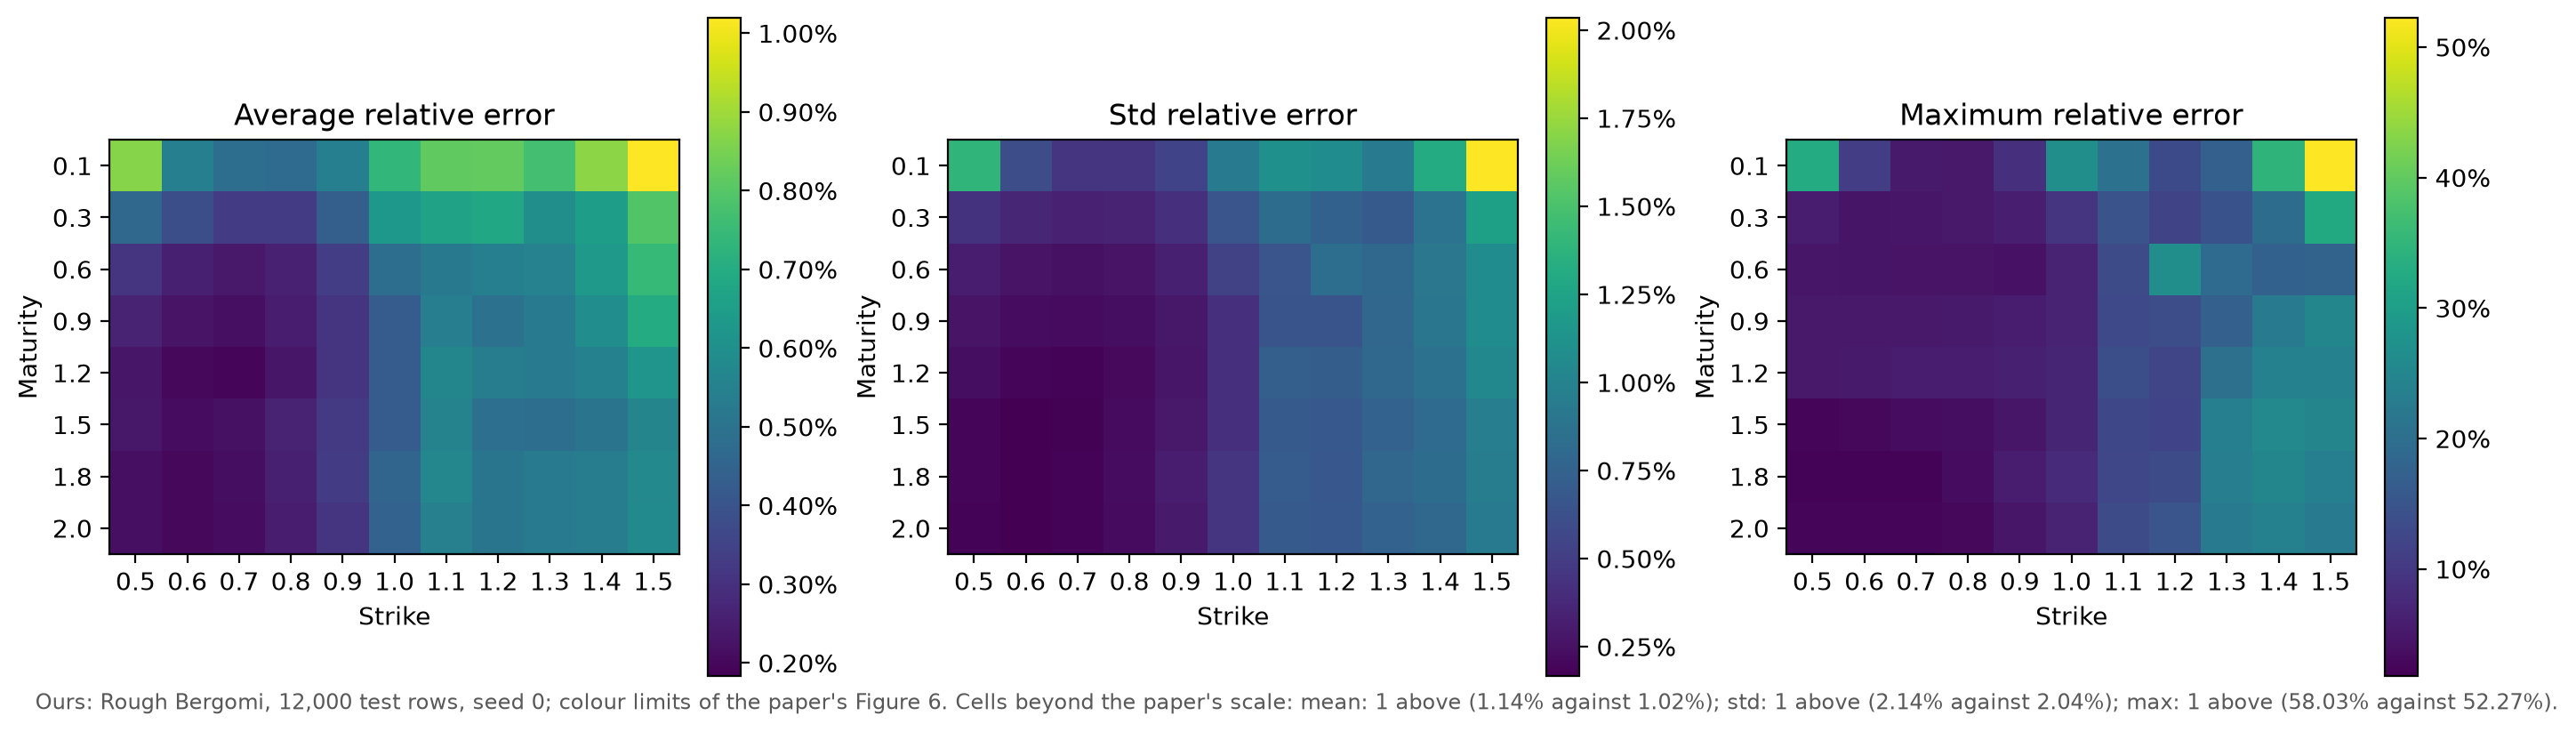

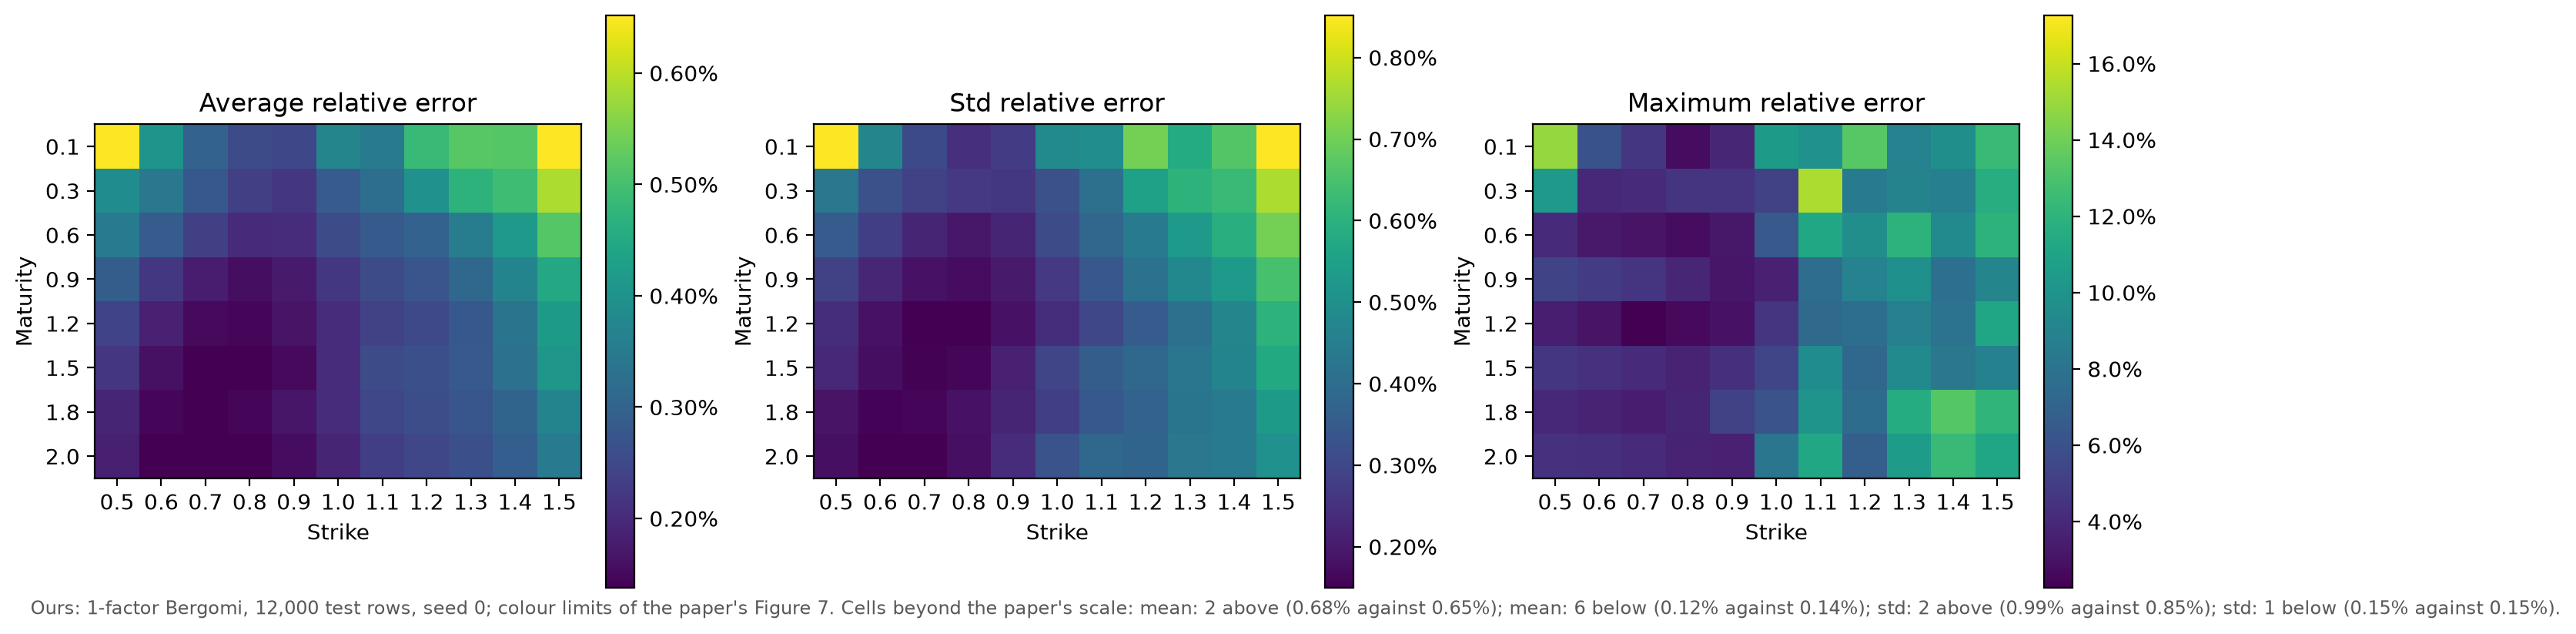

In [7]:
def ms(model, column="avg_rel_error_pct", fmt="{:.3f}%"):
    s = pd.read_csv(f"results/{model}/seeds_test.csv").set_index("seed")
    return f"{fmt.format(s.loc['mean', column])} ± {fmt.format(s.loc['std', column])}"

rows = []
for model, limits_key in (("rbergomi", "fig6_colour_limits_pct"), ("onefactor", "fig7_colour_limits_pct")):
    acc, lim, title = pd.read_csv(f"results/{model}/accuracy_summary_test.csv").set_index("seed").loc[0], PAPER[limits_key][0], DATASETS[model]["title"]
    rows += [{"model": title, "quantity": "average relative error, 5 seeds", "paper": f"far below {PAPER['avg_rel_error_bound_pct'][0]}%", "ours (test set)": ms(model)},
             {"model": title, "quantity": "largest cell average, seed 0", "paper": f"{lim['mean'][1]:.2f}% (top of the colour bar)", "ours (test set)": f"{acc.largest_cell_mean_pct:.2f}%"},
             {"model": title, "quantity": "largest cell standard deviation, seed 0", "paper": f"{lim['std'][1]:.2f}%", "ours (test set)": f"{acc.largest_cell_std_pct:.2f}%"},
             {"model": title, "quantity": "maximum relative error, seed 0", "paper": f"{PAPER['max_rel_error_text_pct'][0]:.0f}% in the text; {lim['max'][1]:.1f}% on the colour bar", "ours (test set)": f"{acc.max_rel_error_pct:.1f}%"},
             {"model": title, "quantity": "share of cells above the 1% bid-ask yardstick", "paper": "not reported", "ours (test set)": f"{100 * acc.share_of_cells_above_1pct:.1f}%"}]
display(pd.DataFrame(rows).set_index(["model", "quantity"]))
print("Our heatmaps, drawn with the paper's layout and colour limits; open the paper's Figure 6 beside them:")
display(Image("results/figures/rbergomi/error_heatmaps_test.png", width=950))
display(Image("results/figures/onefactor/error_heatmaps_test.png", width=950))

### Table B. Speed of one surface (Table 2) — reproduction

Different hardware (a 2026 laptop CPU against the authors' 2019 machine), so the comparison is about the order of magnitude and the ranking. The paper's network time is a hand-written NumPy forward pass, scaled input to scaled output (its notebook, cell 22); we time the same thing, plus the full path from raw parameters to vols and a PyTorch call.

In [8]:
speed = pd.read_csv("results/rbergomi/speed.csv")[["what", "median_us", "timed"]]
speed["median_us"] = speed["median_us"].map(us_to_ms)
paper_speed = {"numpy_forward_scaled": f"{us_to_ms(PAPER['nn_price_us'][0])} (Table 2)", "torch_forward": f"{us_to_ms(NOTEBOOK['rbergomi']['keras_predict_us'][0])} (Keras predict, notebook cell 23)",
               "jacobian_numpy": f"{us_to_ms(PAPER['nn_gradient_us'][0])} (Table 2)"}
speed.insert(1, "paper (ms)", [paper_speed.get(w, "") for w in speed["what"]])
display(speed.rename(columns={"median_us": "ours, median ms"}))
print(f"Monte Carlo pricer: {us_to_ms(PAPER['mc_rbergomi_us'][0])} ms per surface in the paper (Table 2); not reproduced, no simulator is published.")

,what,paper (ms),"ours, median ms",timed
0,numpy_forward_scaled,0.0309 (Table 2),0.00919,"NumPy forward pass, scaled 11-vector in, scaled 88-vector out (what the auth..."
1,numpy_forward_full,,0.0105,NumPy: raw parameters -> scaling -> forward pass -> implied vols
2,torch_forward,"0.469 (Keras predict, notebook cell 23)",0.0146,"PyTorch forward pass under no_grad, one thread, input already a 1 x 11 tenso..."
3,numpy_jacobian,,0.0246,"NumPy analytic 88 x 11 Jacobian, scaled space (counterpart of Table 2's NN g..."
4,torch_autograd_jacobian,,3.09,"torch.autograd.functional.jacobian of the same network, one thread"


Monte Carlo pricer: 500 ms per surface in the paper (Table 2); not reproduced, no simulator is published.


### Table C. Calibration time (Figure 8) and accuracy (Figure 9) — reproduction

The first 5,000 test surfaces, the same ones the authors calibrate (100 for the gradient-free optimizers). The paper's bar heights are read off its Figure 8. Two things to know: the authors' code calls `least_squares` without a method, which runs a trust-region solver (TRF), not Levenberg-Marquardt; and SciPy's COBYLA has been re-implemented since 2019, so its timing is not comparable.

n_surfaces paper, mean ms (read off Figure 8)  ours, mean ms  share_in_box  surface RMSE, 99% quantile (%)
model            optimizer                                                                                                                              
Rough Bergomi    L-BFGS-B                           5000                               24.8          5.327         1.000                           0.341
                 SLSQP                              5000                               20.2          1.704         1.000                           0.341
                 BFGS                               5000                               35.4          4.722         0.792                           0.341
                 Levenberg-Marquardt                5000                               6.81          0.395         0.793                           0.337
                 least_squares default (TRF)        5000                                             0.627         0.793                           0.337
                 COBYLA                              100                              257.0       1923.584         0.970                           0.231
                 Differential Evolution              100                             8820.0        399.664         1.000                           0.230
                 Nelder-Mead                         100                              480.0        109.986         1.000                           1.250
1-factor Bergomi L-BFGS-B                           5000                               29.7          3.477         1.000                           0.230
                 SLSQP                              5000                               17.4          1.551         1.000                           0.230
                 BFGS                               5000                               32.5          4.399         0.902                           0.221
                 Levenberg-Marquardt                5000                               4.86          0.391         0.902                           0.218
                 least_squares default (TRF)        5000                                             0.624         0.902                           0.218
                 COBYLA                              100                              240.0       1836.547         0.970                           0.281
                 Differential Evolution              100                             9440.0        472.632         1.000                           0.280
                 Nelder-Mead                         100                              385.0        110.863         1.000                           3.396

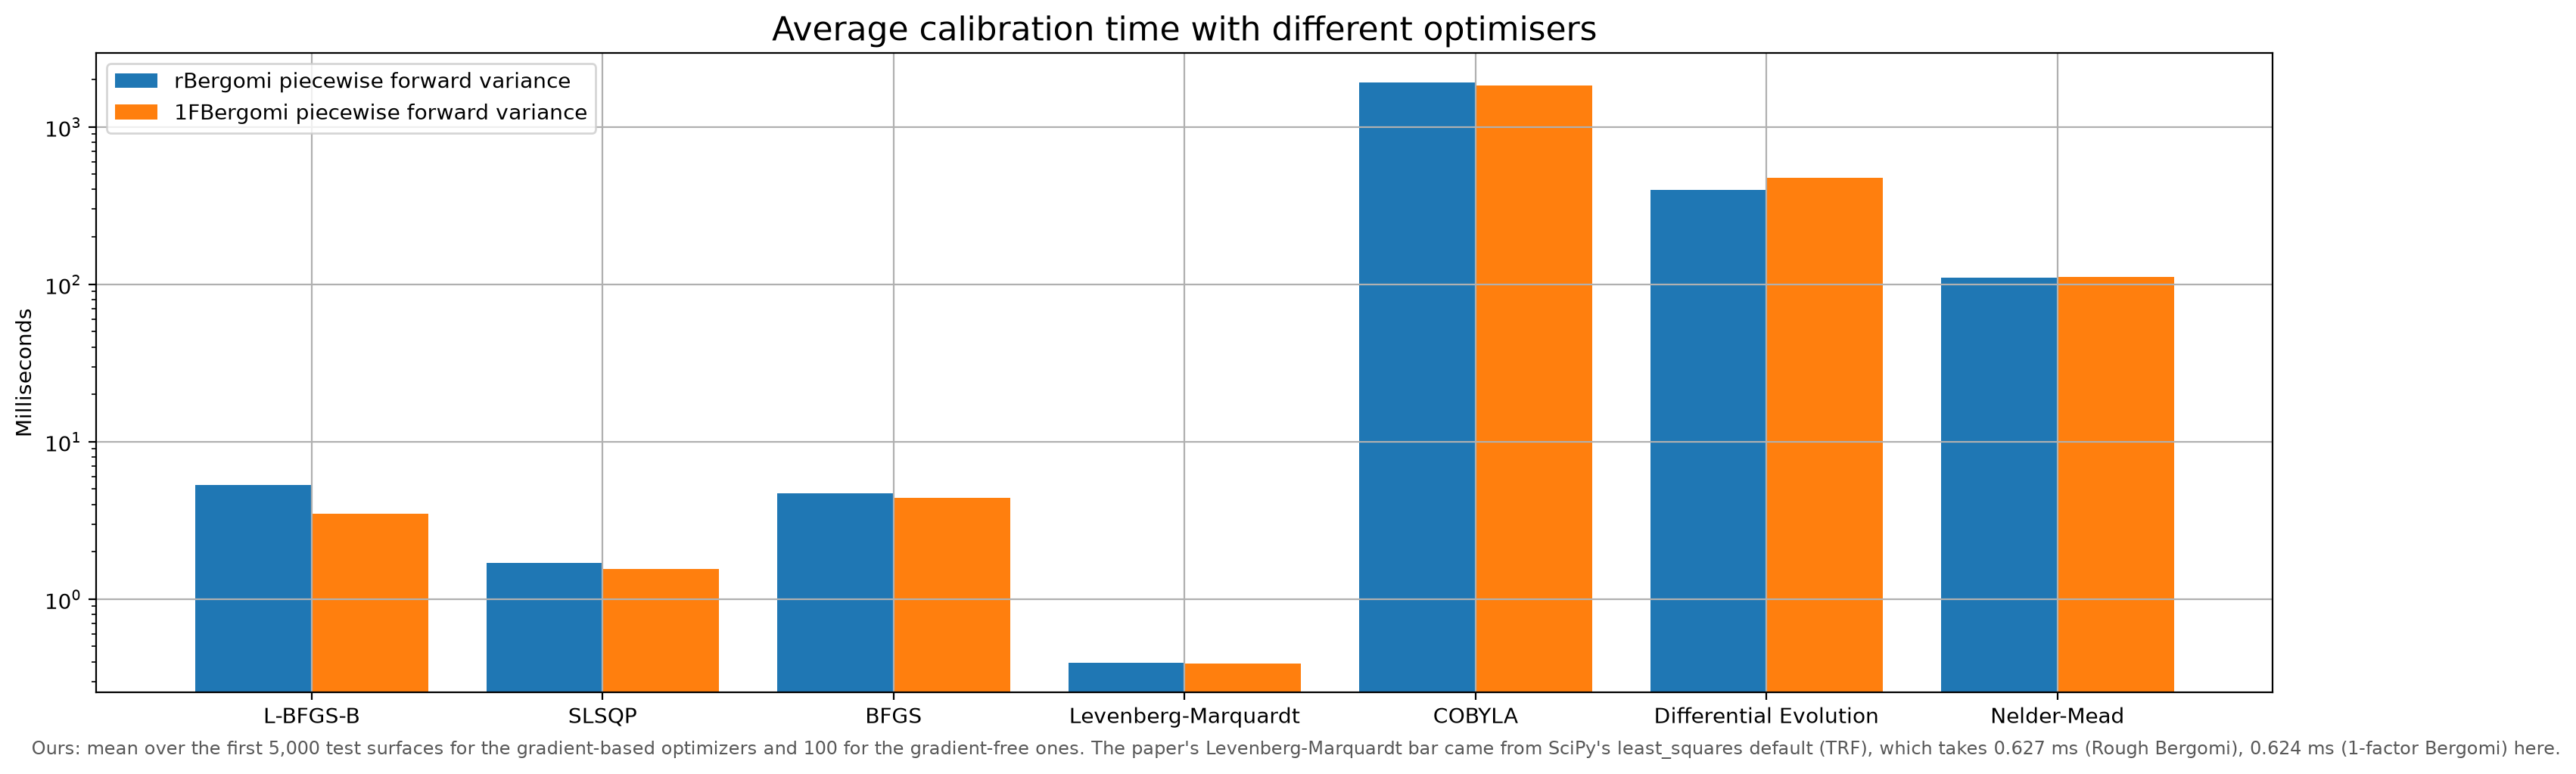

Levenberg-Marquardt, rough Bergomi: surface RMSE 99% quantile 0.34% (paper: below 1.0%); parameter errors:


,"authors' notebook, mean relative error (cell 34)","ours, mean relative error"
parameter,,
xi1,0.99%,1.16%
xi2,1.38%,1.55%
xi3,1.68%,2.27%
xi4,2.62%,3.33%
xi5,4.11%,4.74%
xi6,6.00%,7.74%
xi7,8.57%,9.94%
xi8,15.48%,15.77%
nu,0.76%,0.82%


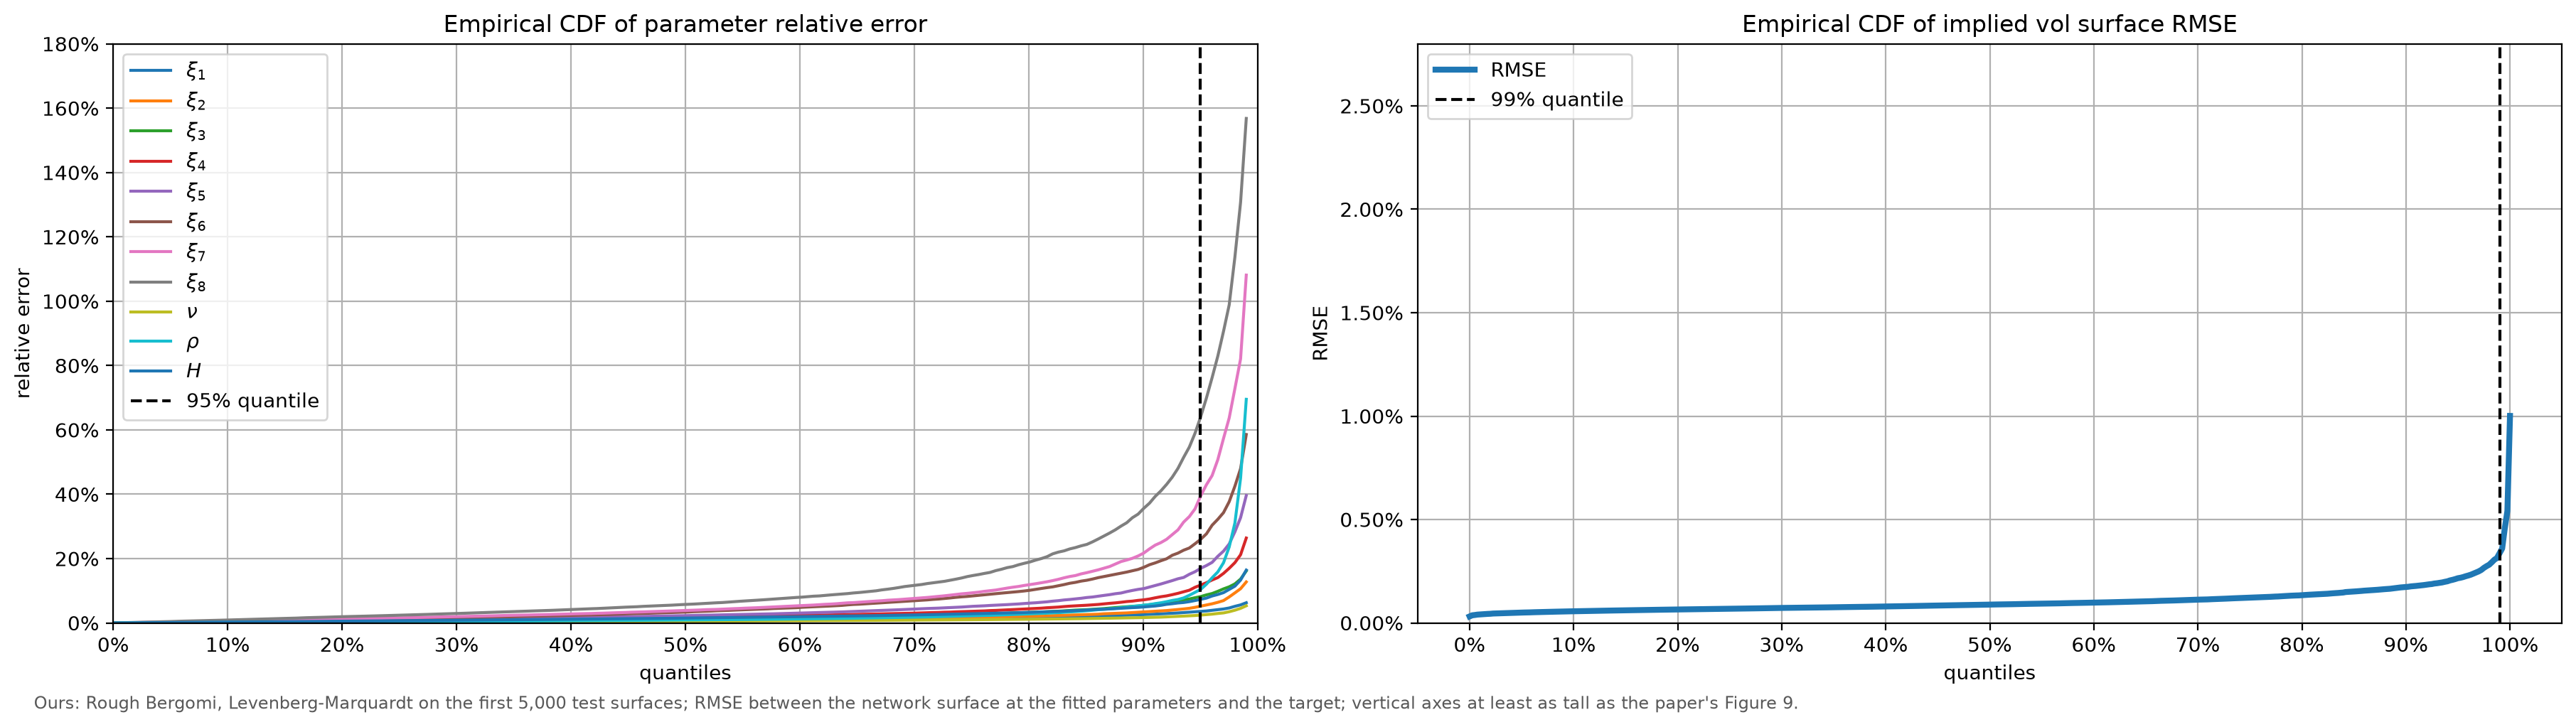

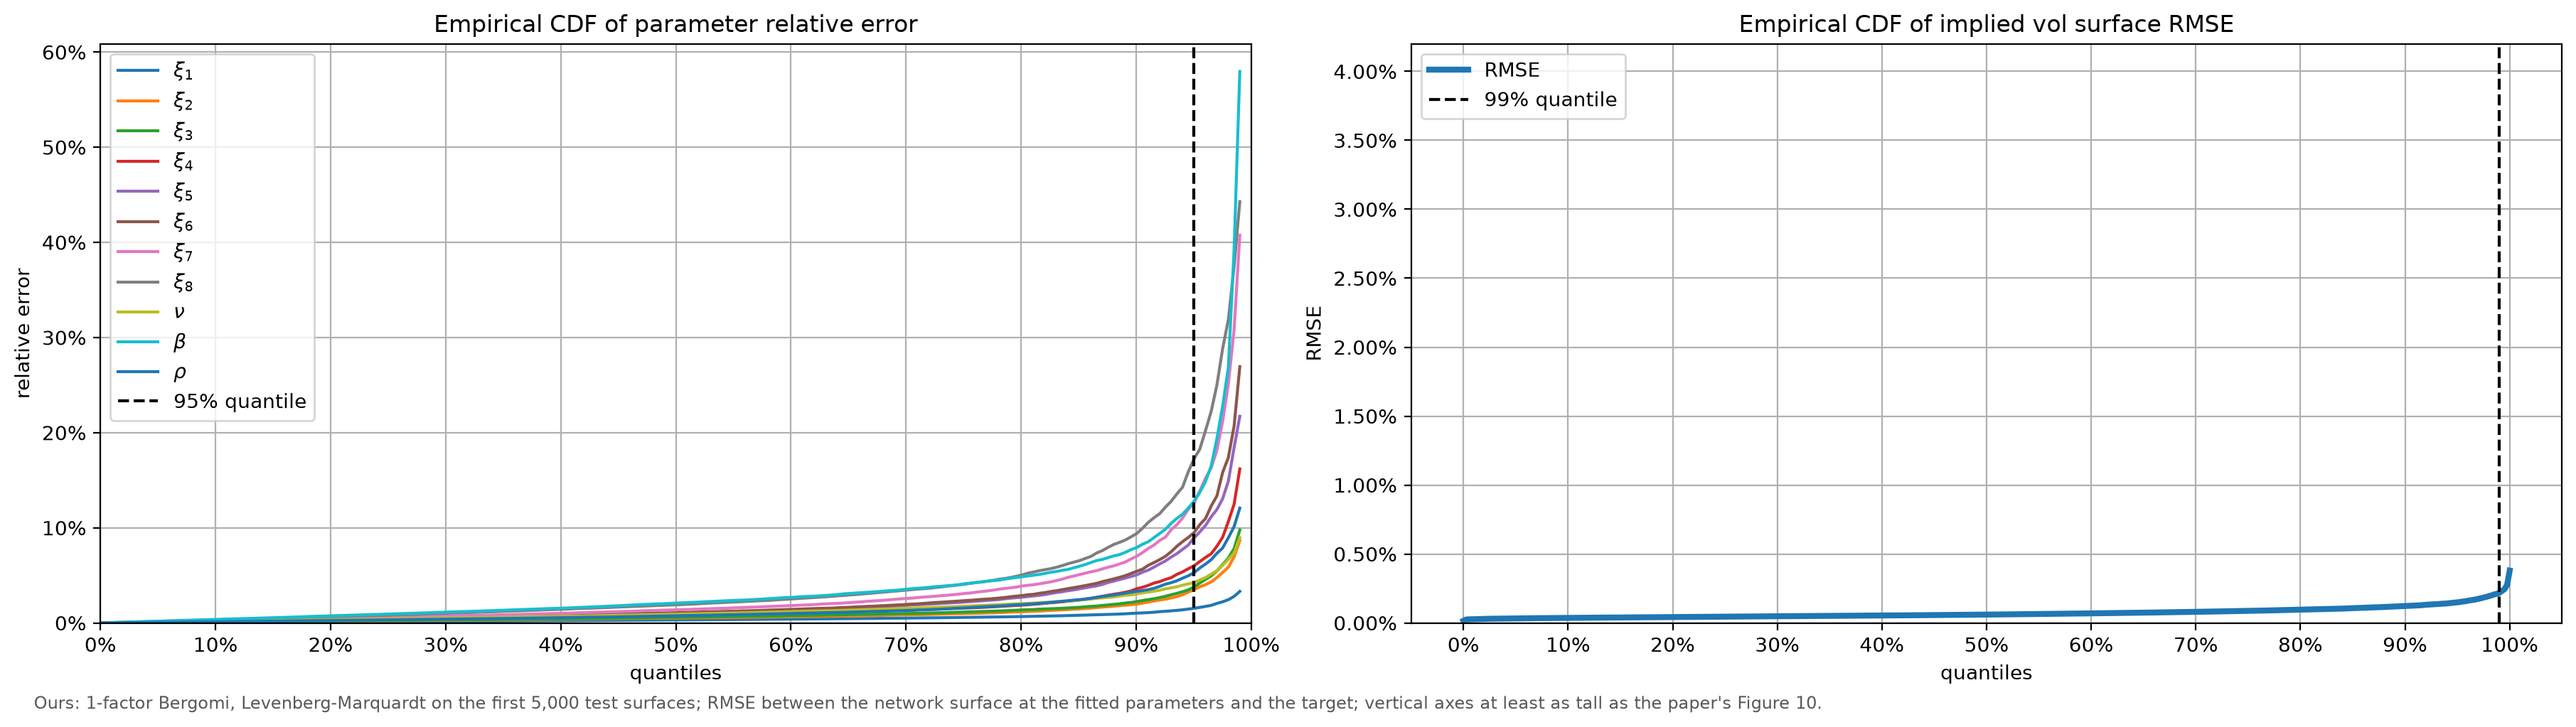

In [9]:
parts = []
for model in DATASETS:
    s = pd.read_csv(f"results/{model}/calibration_summary_test.csv")
    s.insert(1, "model", DATASETS[model]["title"])
    s["paper, mean ms (read off Figure 8)"] = [PAPER["fig8_mean_ms"][0][model].get(o, "") for o in s["optimizer"]]
    parts.append(s[["model", "optimizer", "n_surfaces", "paper, mean ms (read off Figure 8)", "mean_ms", "share_in_box", "rmse_q99_pct"]])
display(pd.concat(parts).round(3).rename(columns={"mean_ms": "ours, mean ms", "rmse_q99_pct": "surface RMSE, 99% quantile (%)"}).set_index(["model", "optimizer"]))
display(Image("results/figures/calibration_times_test.png", width=950))

errors = pd.read_csv("results/rbergomi/calibration_param_errors_test.csv")
lm = errors[errors.optimizer == "Levenberg-Marquardt"].set_index("parameter")
notebook_errors = NOTEBOOK["rbergomi"]["lm_mean_rel_error"][0]
table = pd.DataFrame({"authors' notebook, mean relative error (cell 34)": [f"{100 * v:.2f}%" for v in notebook_errors],
                      "ours, mean relative error": [f"{v:.2f}%" for v in lm["mean_pct"]]}, index=lm.index)
print(f"Levenberg-Marquardt, rough Bergomi: surface RMSE 99% quantile {float(parts[0].loc[parts[0].optimizer == 'Levenberg-Marquardt', 'rmse_q99_pct'].iloc[0]):.2f}% "
      f"(paper: below {PAPER['rmse_q99_bound_pct'][0]}%); parameter errors:")
display(table)
display(Image("results/figures/rbergomi/calibration_errors_test.png", width=950))
display(Image("results/figures/onefactor/calibration_errors_test.png", width=950))

### Our upgrades

The paper contains none of what follows. We added three upgrades: a **fixed flaw** (the paper's early stopping watched its test set, and it reports one run), a **robustness check** (the paper never tests the edge of its parameter box, where its own market fits sit) and a **missing baseline** (nobody had checked whether a simpler regressor does as well). Two more analyses give evidence for the critique.

#### Table D. Upgrade 1: a locked test set and five seeds

validation 0.457% against test 0.459% ± 0.012% over 5 seeds: no decision was tuned to rows that fail to generalise


,avg_rel_error_pct,largest_cell_mean_pct,max_rel_error_pct
seed,,,
0,0.465,1.138,58.031
1,0.446,1.080,59.463
2,0.467,1.213,55.868
3,0.471,1.115,51.691
4,0.444,1.007,50.058


the size of the flaw: training the authors' way (test-set stopping, last-epoch weights) against our protocol, same seed:


,protocol,n_train,epochs_run,avg_rel_error_pct,max_rel_error_pct
0,"paper: 68,000 rows, early stopping on the test set, last-epoch weights",68000,241.0,0.437,55.208
1,"ours: 60,000 rows, early stopping on 8,000 validation rows, best weights, te...",60000,NaN,0.465,58.031


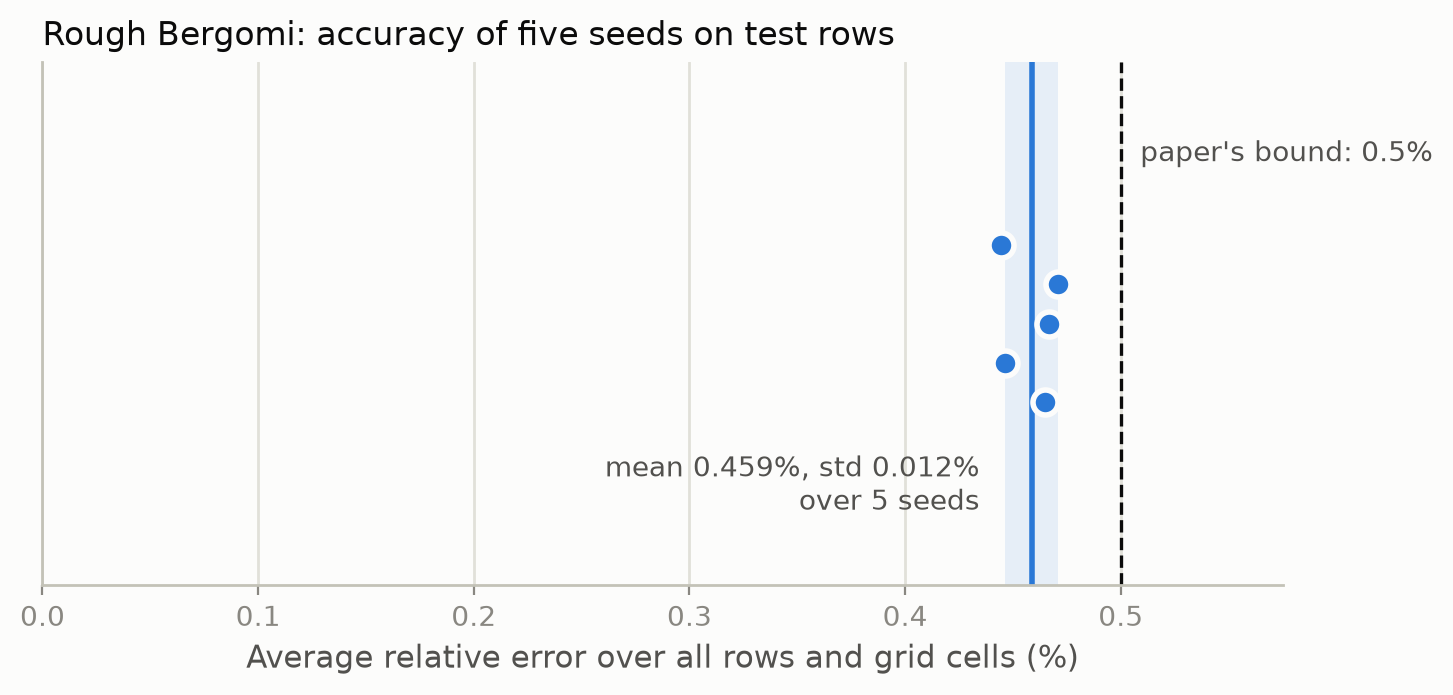

In [10]:
val, test = [pd.read_csv(f"results/rbergomi/seeds_{s}.csv").set_index("seed") for s in ("val", "test")]
print(f"validation {val.loc['mean', 'avg_rel_error_pct']:.3f}% against test {ms('rbergomi')} over {len(SEEDS)} seeds: no decision was tuned to rows that fail to generalise")
test.index = test.index.astype(str)
display(test.loc[[str(s) for s in SEEDS], ["avg_rel_error_pct", "largest_cell_mean_pct", "max_rel_error_pct"]].round(3))
pp = pd.read_csv("results/rbergomi/paper_protocol.csv")[["protocol", "n_train", "epochs_run", "avg_rel_error_pct", "max_rel_error_pct"]]
print("the size of the flaw: training the authors' way (test-set stopping, last-epoch weights) against our protocol, same seed:")
display(pp.round(3))
display(Image("results/figures/rbergomi/seeds_test.png", width=650))

#### Table E. Upgrade 2: the edge of the training box

only 2.45% of training rows lie in the lowest 5% of the rho range (uniform sampling would give 5%): the corner the paper's SPX fits sit in is the thinnest


n_rows  mean_row_error_pct  p95_row_error_pct
parameter region                                                     
rho       below_-0.9       868               1.052              2.230
          rest           11132               0.419              0.801
H         below_0.05       650               0.554              0.943
          rest           11350               0.460              0.996
nu        inside         10850               0.454              0.977
          lowest_5pct      529               0.486              0.923
          highest_5pct     621               0.631              1.274
rho       inside         11002               0.444              0.907
          lowest_5pct      328               1.254              2.637
          highest_5pct     670               0.426              0.729
H         inside         10796               0.454              0.986
          lowest_5pct      626               0.555              0.957
          highest_5pct     578               0.562              1.260

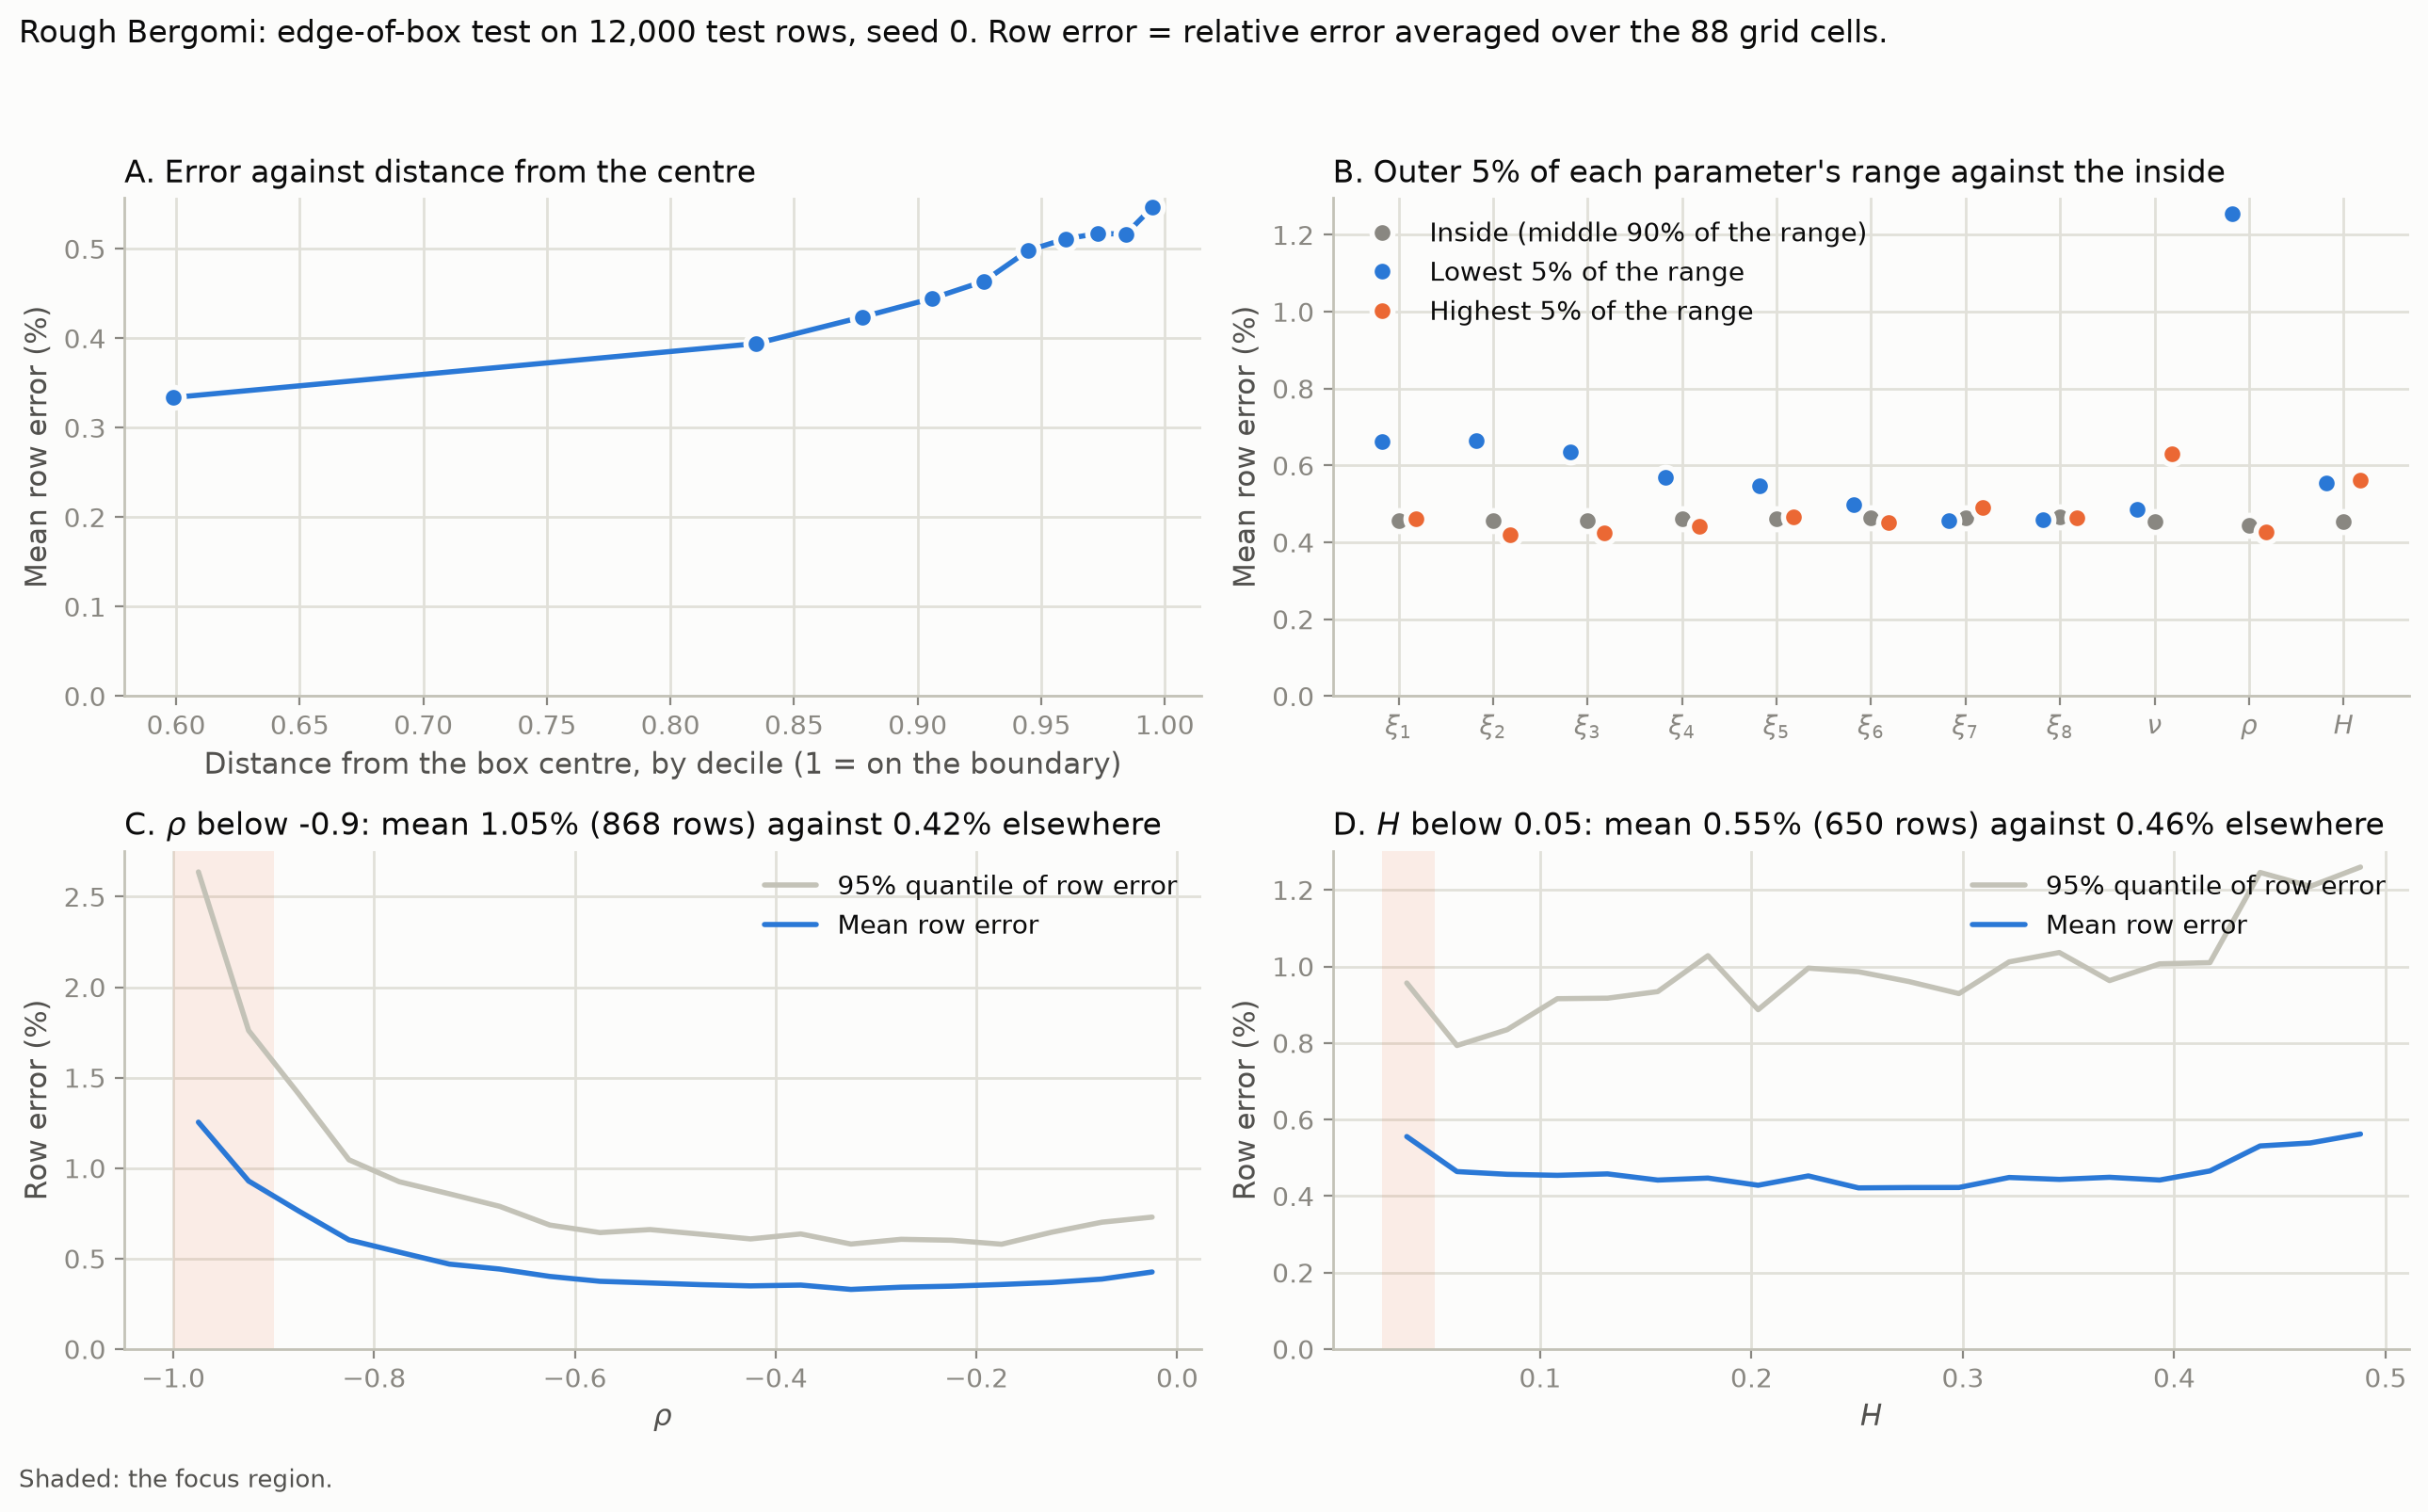

In [11]:
edge = pd.read_csv("results/rbergomi/edge_of_box_test.csv")
focus = edge[edge.analysis == "focus_region"][["parameter", "region", "n_rows", "mean_row_error_pct", "p95_row_error_pct"]]
band = edge[(edge.analysis == "outer_band") & edge.parameter.isin(["rho", "H", "nu"])][["parameter", "region", "n_rows", "mean_row_error_pct", "p95_row_error_pct"]]
share_low_rho = facts["share_in_lowest_5pct"]["rho"]
print(f"only {100 * share_low_rho:.2f}% of training rows lie in the lowest 5% of the rho range (uniform sampling would give 5%): the corner the paper's SPX fits sit in is the thinnest")
display(pd.concat([focus, band]).round(3).set_index(["parameter", "region"]))
display(Image("results/figures/rbergomi/edge_of_box_test.png", width=950))

#### Table F. Upgrade 3: baselines and sample efficiency

,setting,fit_seconds,avg_rel_error_pct,max_rel_error_pct,gap to the network (%),ms per surface
method,,,,,,
"Neural network (ours, seed 0)","4 x 30 ELU, NumPy forward pass",NaN,0.465,58.031,0.000,0.00996
Ridge on polynomial features,"degree 5, alpha 0.001",3.489,0.277,40.291,0.517,0.109
k-nearest neighbours,"k = 20, distance weights",0.013,4.788,131.596,4.806,0.34
Gradient boosting,"300 rounds, learning rate 0.1, one model per cell",10.742,0.983,32.114,1.079,861


test error against the number of training rows (mean and std over seeds):


,mean,std,count
n_train,,,
5000,0.714,0.004,3
10000,0.620,0.038,3
20000,0.526,0.030,3
40000,0.457,0.007,3
60000,0.459,0.011,3


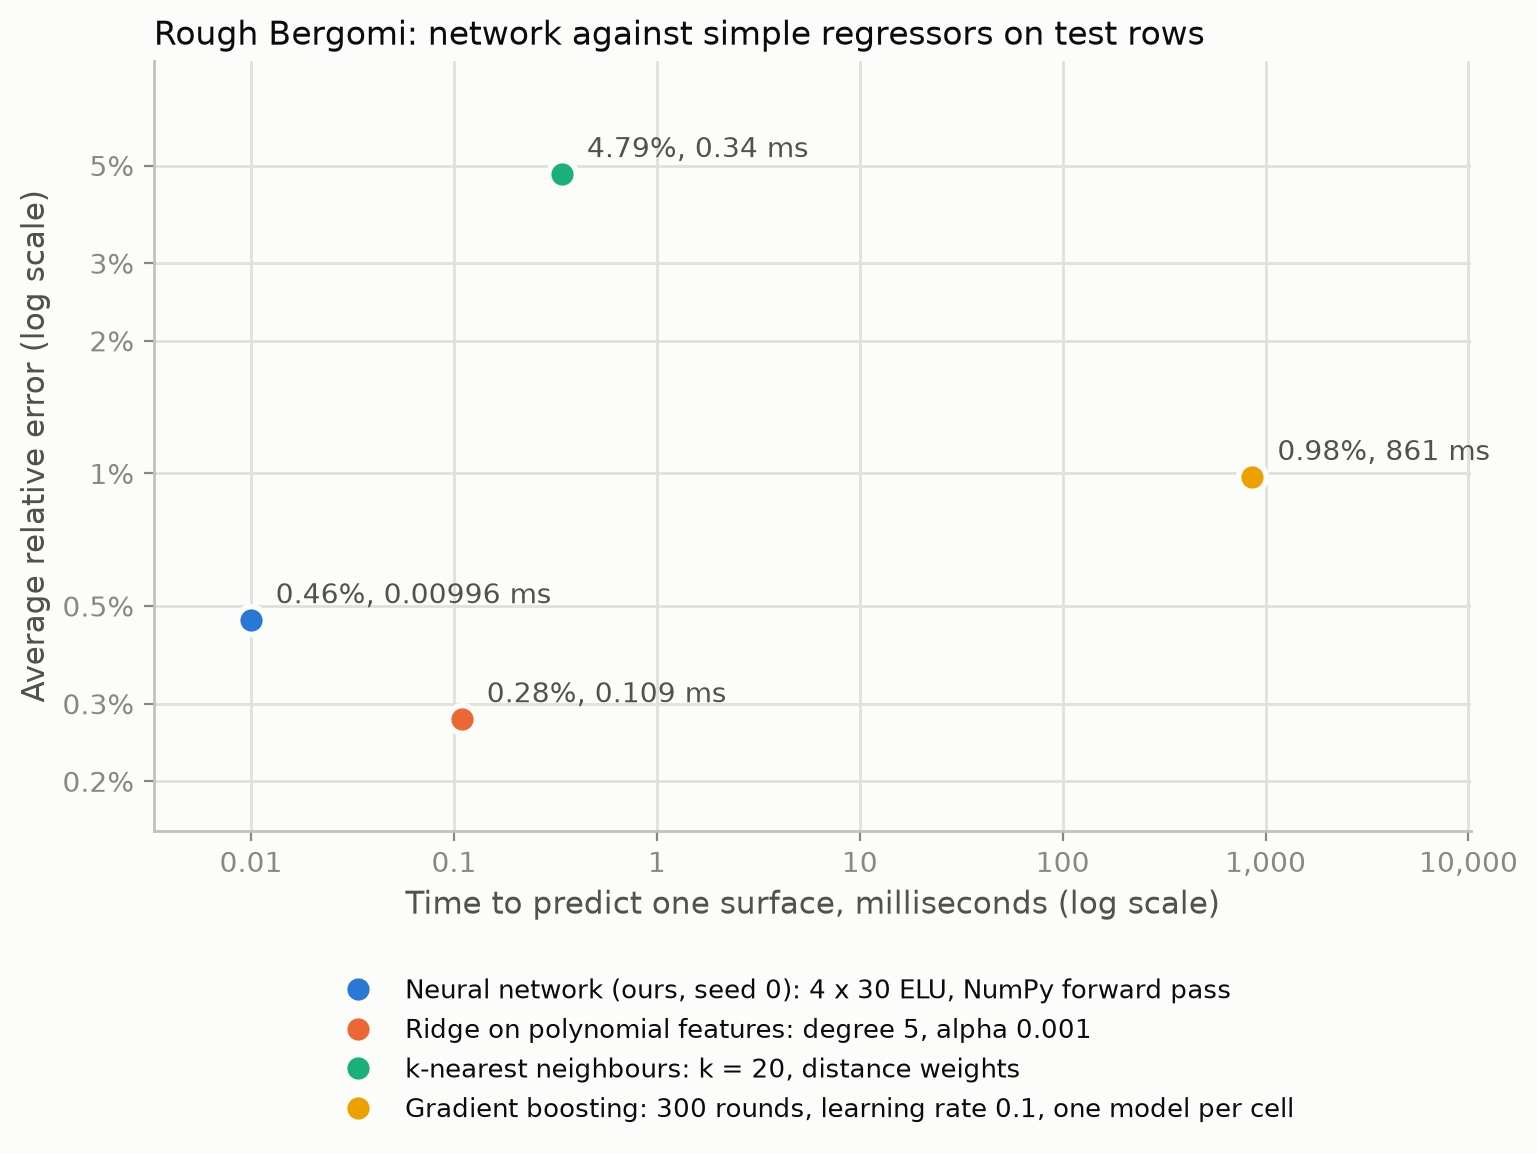

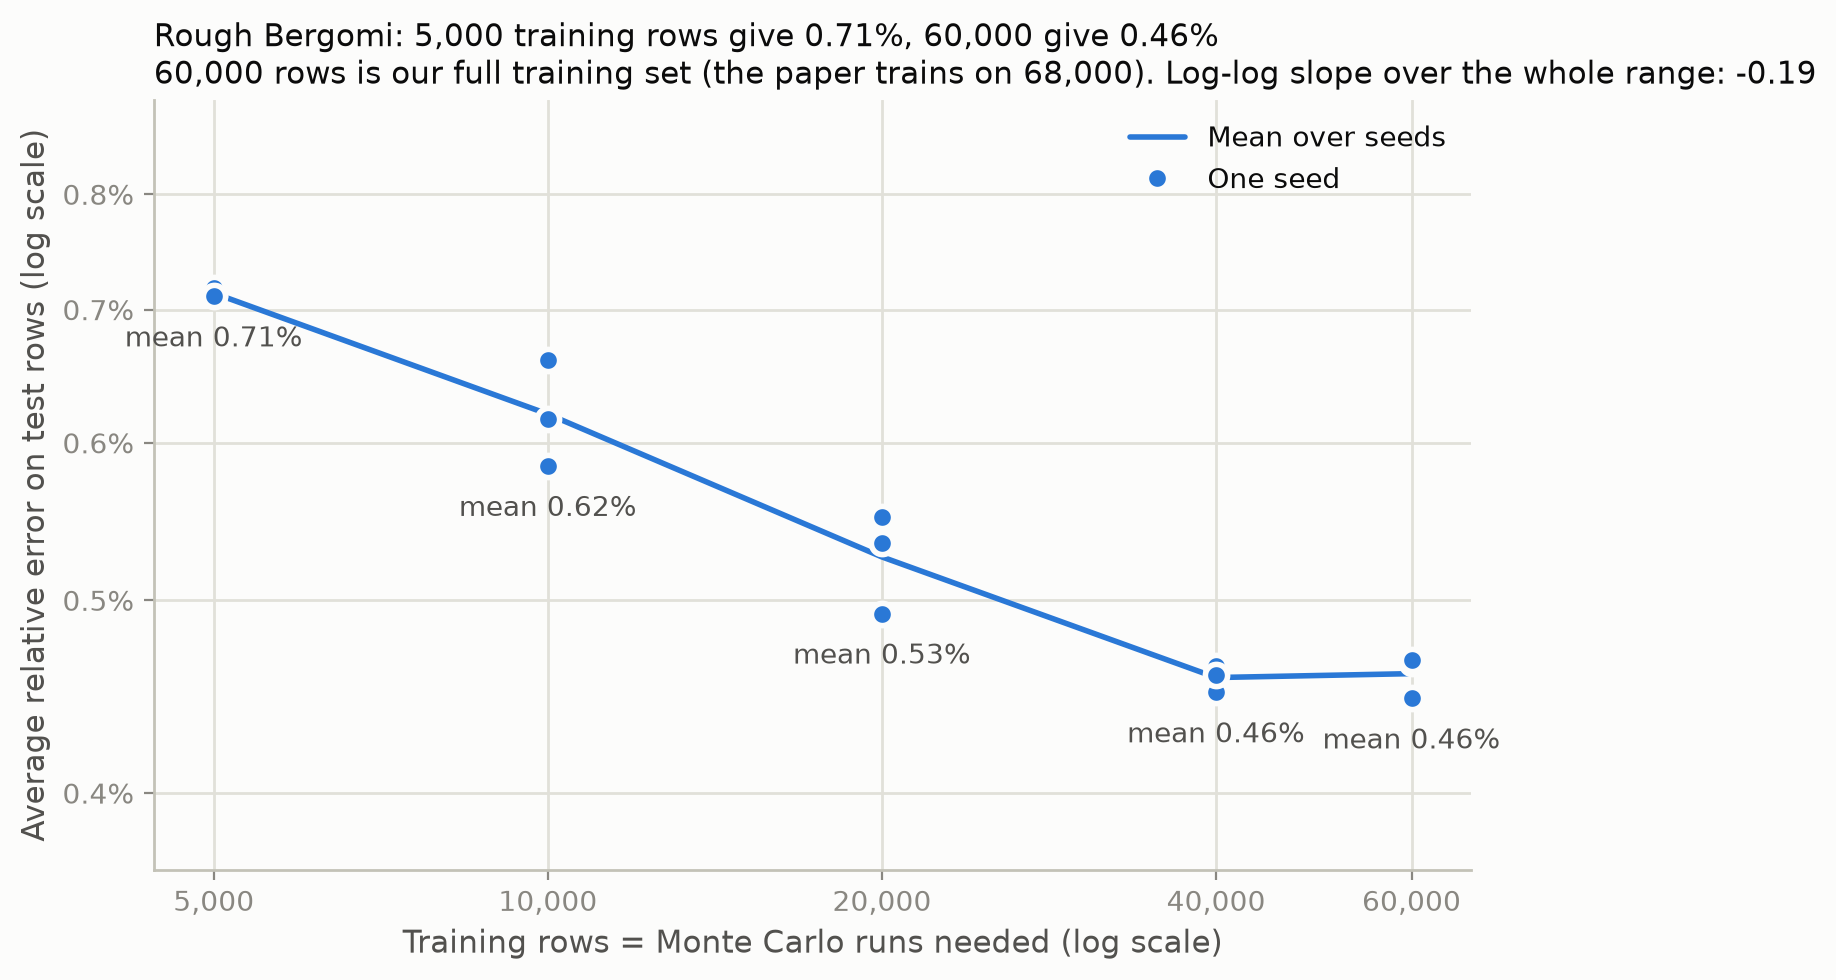

In [12]:
base = pd.read_csv("results/rbergomi/baselines_test.csv")[["method", "setting", "fit_seconds", "avg_rel_error_pct", "max_rel_error_pct", "avg_rel_gap_to_network_pct", "predict_us_median"]]
shown = base.round(3).assign(predict_us_median=base["predict_us_median"].map(us_to_ms))
display(shown.rename(columns={"predict_us_median": "ms per surface", "avg_rel_gap_to_network_pct": "gap to the network (%)"}).set_index("method"))
eff = pd.read_csv("results/rbergomi/sample_efficiency_test.csv").groupby("n_train")["avg_rel_error_pct"].agg(["mean", "std", "count"]).round(3)
print("test error against the number of training rows (mean and std over seeds):")
display(eff)
display(Image("results/figures/rbergomi/baselines_test.png", width=650))
display(Image("results/figures/rbergomi/sample_efficiency_test.png", width=650))

#### Critique evidence: where the largest errors live, and the offline cost

where the largest error of the worst 1% of test rows (largest error above 12.6%) sits, top cells:


,maturity,strike,n_worst_rows
0,0.1,1.5,50
1,0.1,0.5,28
2,0.3,1.5,6
3,0.1,1.0,5
4,0.1,1.1,5
5,1.5,1.5,3


,value,unit,source
quantity,,,
training_samples,80000.000,surfaces,"paper, Section 2.4.1, p. 10"
mc_seconds_per_surface,0.500,s,"paper, Table 2, p. 18"
offline_mc_cpu_hours,11.111,h,paper's numbers multiplied: samples x seconds per surface
network_training_minutes,1.416,min,"ours, train_summary_seed0.json (one CPU thread)"
lm_evaluations_per_calibration,7.527,evaluations,"ours, calibration_summary_val.csv"
mc_surfaces_per_calibration,90.329,surfaces,assumption: 1 + 11 surfaces per evaluation (finite differences)
mc_seconds_per_calibration,45.164,s,assumption x paper's seconds per surface
network_ms_per_calibration,0.411,ms,"ours, calibration_summary_val.csv"
break_even_calibrations,887.542,calibrations,offline cost / time saved per calibration


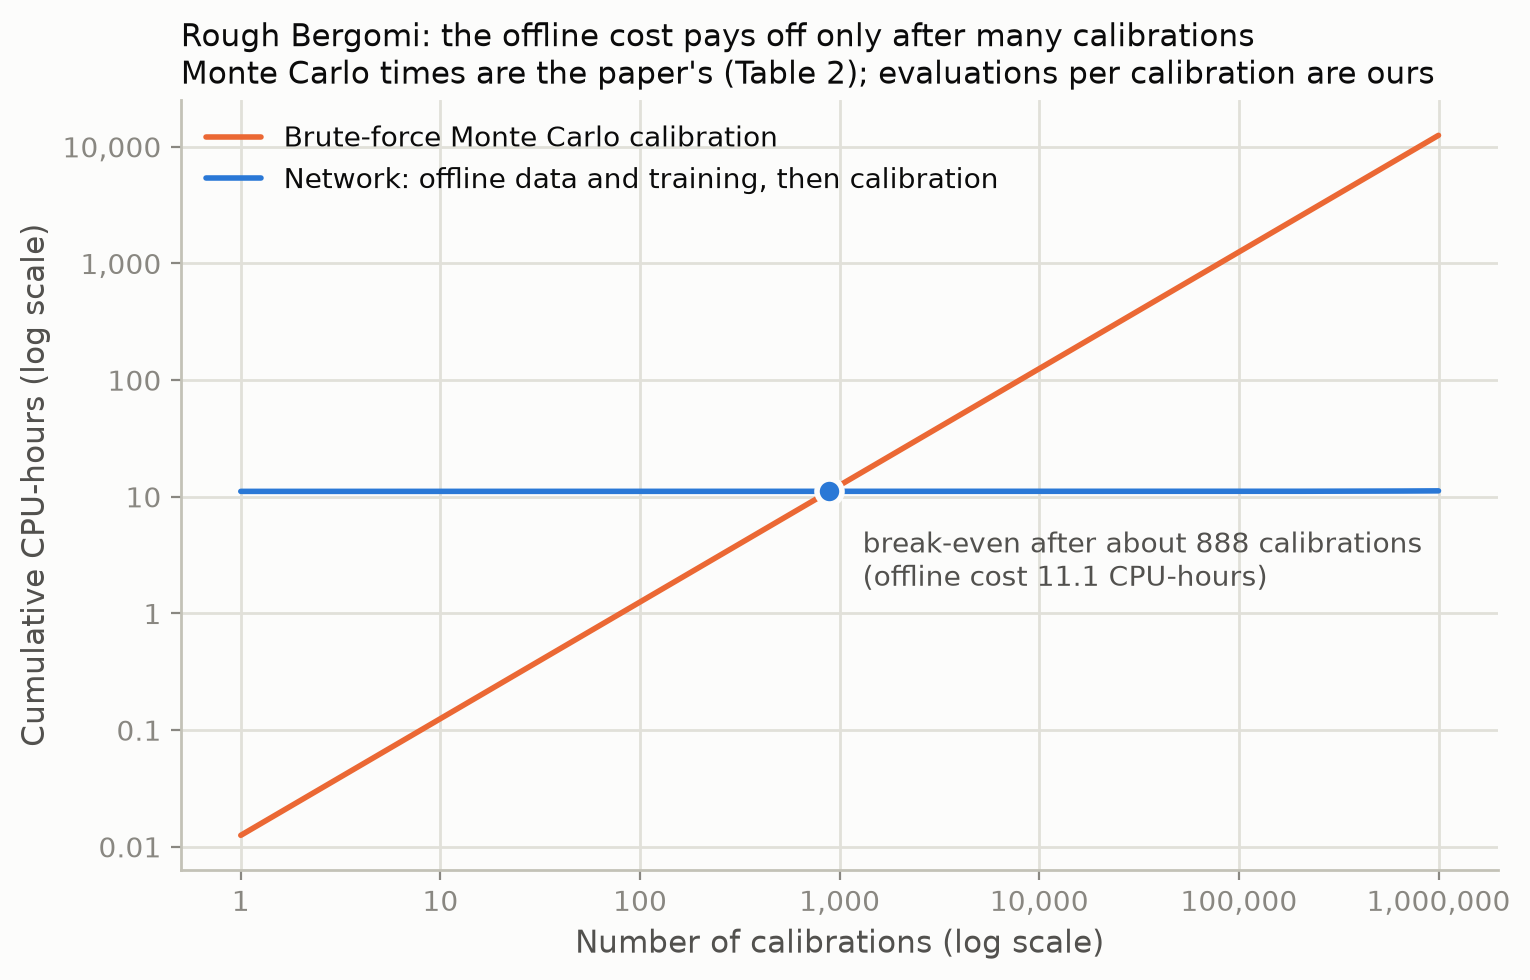

In [13]:
worst = pd.read_csv("results/rbergomi/worst_errors_test.csv")
cells = worst[worst.analysis == "worst_cell"].sort_values("n_worst_rows", ascending=False)[["maturity", "strike", "n_worst_rows"]].head(6)
threshold = worst.loc[worst.analysis == "worst_cell", "worst_row_threshold_pct"].iloc[0]
print(f"where the largest error of the worst 1% of test rows (largest error above {threshold:.1f}%) sits, top cells:")
display(cells.reset_index(drop=True))
cost = pd.read_csv("results/rbergomi/offline_cost.csv")
display(cost.round(3).set_index("quantity"))
display(Image("results/figures/rbergomi/offline_cost.png", width=650))

### Stretch experiments

Run after every acceptance check had passed, each to answer one likely question: does the smooth activation matter (ELU against ReLU, validation rows); how much do noisy quotes move the parameters (validation rows); and do the authors' own published calibrations of the same test surfaces agree with ours, including their Figure 9 RMSE recomputed exactly as their notebook does.

,val_avg_rel_error_pct,lm_mean_evaluations,rmse_q99_pct,share_in_box,mean_param_error_pct
activation,,,,,
elu,0.461,7.476,0.338,0.804,4.936
relu,0.758,11.589,0.424,0.542,16.362


parameter,xi1,xi2,xi3,xi4,xi5,xi6,xi7,xi8,nu,rho,H
clean_median_pct,0.740,0.824,1.202,1.801,2.381,3.013,3.628,5.666,0.535,0.906,1.520
noisy_median_pct,0.824,0.983,1.463,2.676,3.730,4.969,6.403,10.428,0.652,1.045,1.876


the authors' published fit against ours on the same test surfaces (their notebook's cell 34 numbers are reproduced from their file):


,authors_mean_pct,ours_lm_mean_pct,authors_median_pct,ours_lm_median_pct,gap_trf_median_pct
parameter,,,,,
xi1,0.991,1.163,0.640,0.777,1.097
xi2,1.385,1.551,0.801,0.838,1.079
xi3,1.682,2.272,0.850,1.183,1.346
xi4,2.617,3.330,1.232,1.750,2.087
xi5,4.112,4.743,1.876,2.271,2.883
xi6,6.004,7.739,2.692,3.361,3.964
xi7,8.570,9.944,3.074,3.857,4.697
xi8,15.478,15.768,5.460,5.749,6.721
nu,0.764,0.823,0.498,0.527,0.602


,n_surfaces,n_dropped,n_rows_with_zero_vol,median_pct,q99_pct,max_pct
definition,,,,,,
paper_as_coded,4941,59,13,0.106,0.354,2.707
paper_as_coded_no_zero_vols,4928,72,0,0.105,0.333,0.772
ours_lm,5000,0,0,0.089,0.337,1.001
ours_trf,5000,0,0,0.089,0.337,1.001
authors_params_our_network,5000,0,0,0.163,0.428,1.818


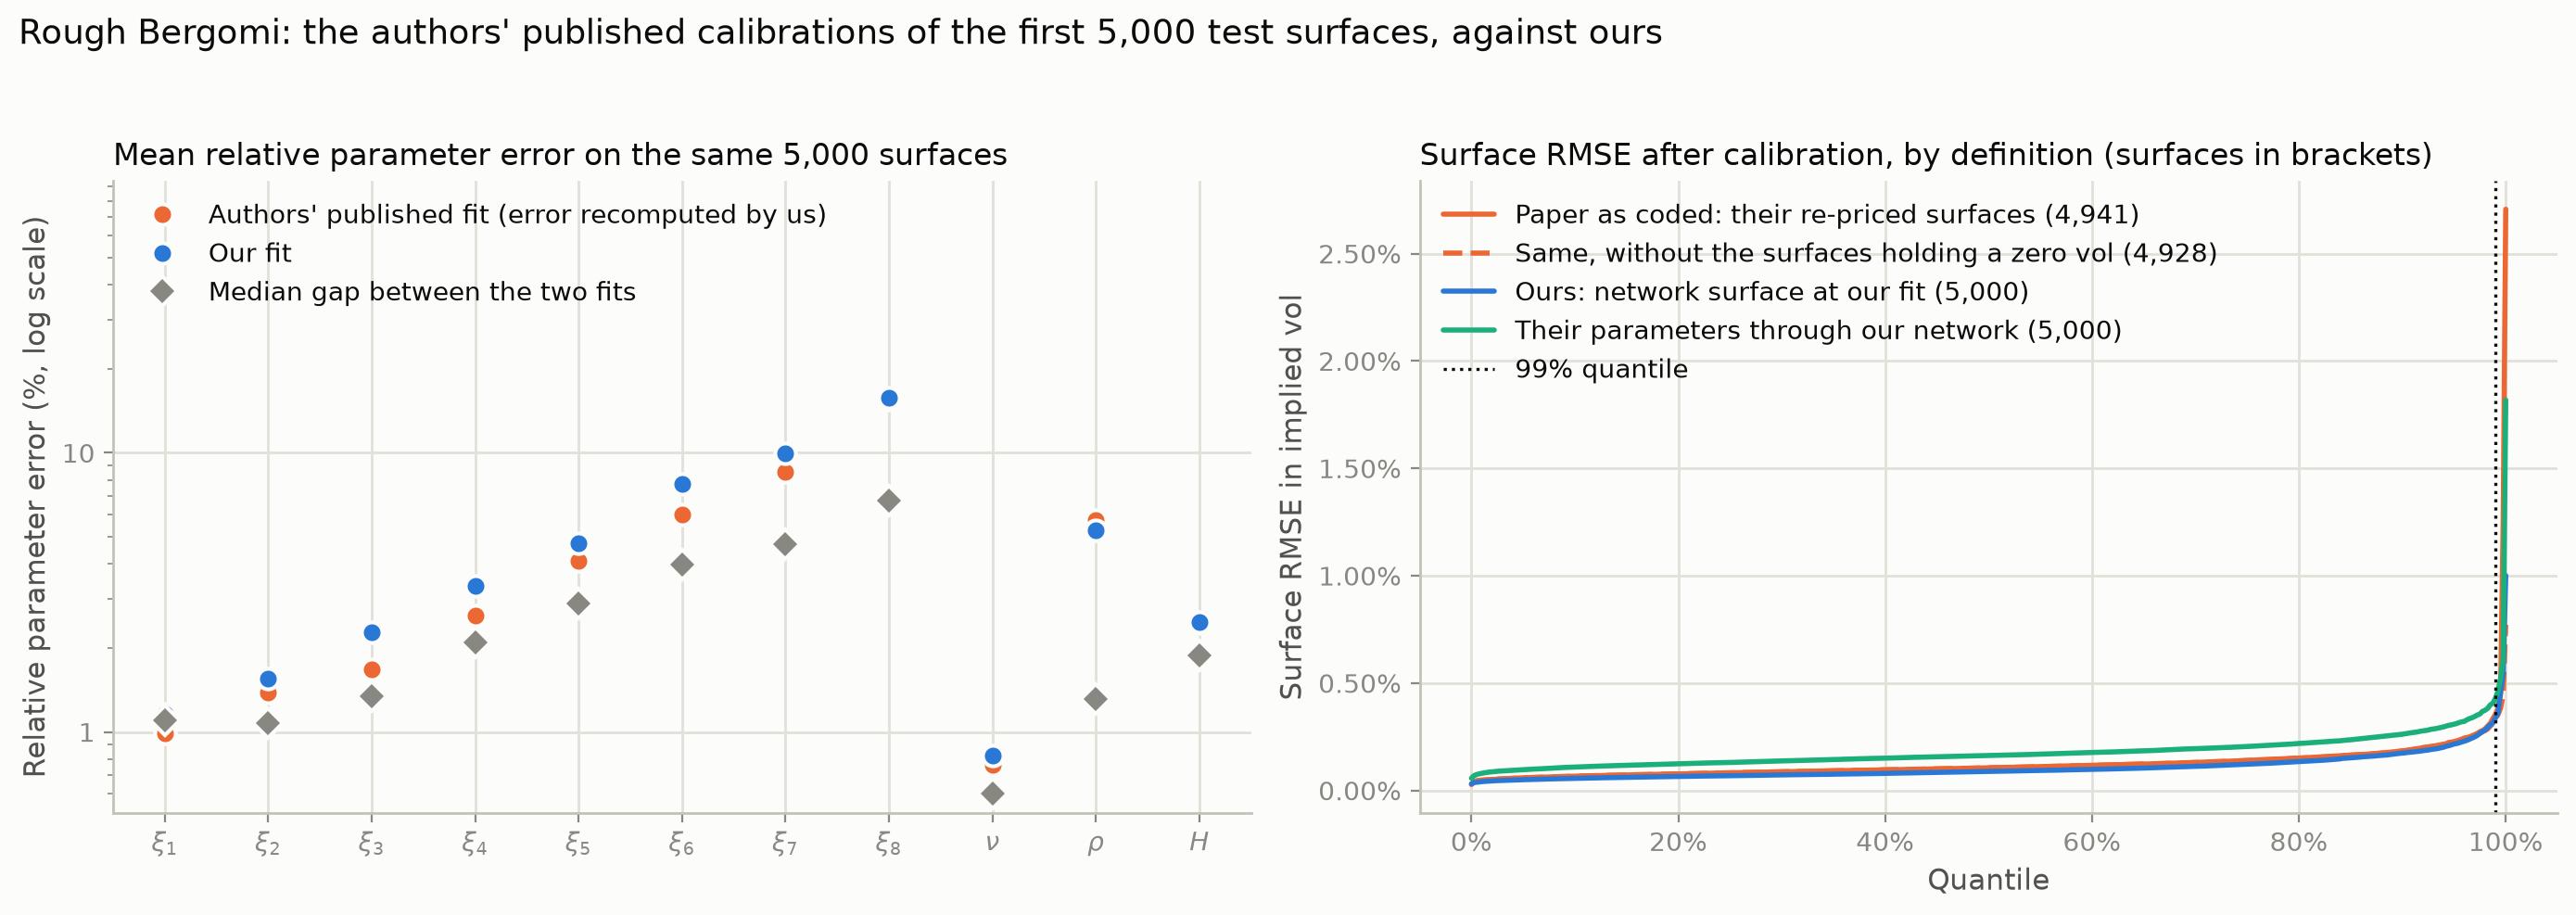

In [14]:
abl = pd.read_csv("results/rbergomi/ablation_activation_val.csv").set_index("activation")[["val_avg_rel_error_pct", "lm_mean_evaluations", "rmse_q99_pct", "share_in_box", "mean_param_error_pct"]]
display(abl.round(3))
noise = pd.read_csv("results/rbergomi/noise_robustness_val.csv").set_index("parameter")[["clean_median_pct", "noisy_median_pct"]]
display(noise.round(3).T)
authors = pd.read_csv("results/rbergomi/authors_calibration_params_test.csv").set_index("parameter")[["authors_mean_pct", "ours_lm_mean_pct", "authors_median_pct", "ours_lm_median_pct", "gap_trf_median_pct"]]
print("the authors' published fit against ours on the same test surfaces (their notebook's cell 34 numbers are reproduced from their file):")
display(authors.round(3))
rmse = pd.read_csv("results/rbergomi/authors_calibration_rmse_test.csv")[["definition", "n_surfaces", "n_dropped", "n_rows_with_zero_vol", "median_pct", "q99_pct", "max_pct"]]
display(rmse.round(3).set_index("definition"))
display(Image("results/figures/rbergomi/authors_calibration_test.png", width=950))

### Where the paper, its code and its data disagree

Built by `src/report.py` from the data, the paper and the authors' notebooks, with the evidence for every row; `python -m src.report --discrepancies` prints the same table.

In [15]:
from src.report import discrepancies_markdown
display(Markdown(discrepancies_markdown(with_header=False)))

We read the notebooks to document these differences. We copied no code from them and never loaded their weights.

## 1. Six differences we checked first, re-verified

| # | Item | Paper | Authors' code and data | What we do |
| --- | --- | --- | --- | --- |
| 1 | Number of weights | 6,808 (Section 4.1.1, p. 20; the formula 30n + 6478 is in Section 3.2.1, p. 15, item 4) | 5,878: the model summary in cell 11 lists layers of 360, 930, 930, 930, 2728 weights | Our network has 5,878 weights, asserted in `src/tests/`. The paper's formula counts four hidden-to-hidden maps; four hidden layers have three, and 3 instead of 4 gives 5,878 instead of 6,808 |
| 2 | Range of rho, rough Bergomi | Uniform on [-0.95, -0.1] (Section 4.1.1, p. 20, sampling box of both models) | The data file spans -0.99999 to -0.00002; cell 8 scales with bounds [-1, 0]. The paper itself uses [-1, 0] for SPX (Section 4.2.2, p. 24, box used for the SPX calibration) | Scale with [-1, 0], the box the data was drawn from |
| 3 | Epochs | 200 (Section 3.2.2, p. 16, item 1) | Up to 500 (cell 13); training stopped at epoch 261 for rough Bergomi and 189 for 1-factor | Allow 500, as the code that produced the published weights did |
| 4 | Early stopping | Stops when the error on the test set has not improved for 25 steps (Section 3.2.2, p. 16, item 1) | Cell 13 passes the test arrays as `validation_data`, so the test set steers training and no untouched test set remains | Stop on a separate validation set of 8,000 rows; the 12,000 test rows stay locked until the final evaluation |
| 5 | Data behind Figures 6 and 7 | The captions say all 68,000 training samples (pp. 20-21) | Cell 25 computes the errors on `X_test`, and the heading above it (cell 24) says "Test set" | Show training, validation and test heatmaps separately and say which is which |
| 6 | Network pricing time | 0.0309 milliseconds (Table 2, p. 18) | Cell 22 times a hand-written NumPy forward pass: 0.0309 milliseconds. Cell 23 times Keras `predict`: 0.469 milliseconds | Time both a NumPy forward pass and PyTorch, and say which number is which |

## 2. Further differences we found

| # | Item | Paper | Authors' code and data | What we do |
| --- | --- | --- | --- | --- |
| 7 | The optimizer called Levenberg-Marquardt | Section 4.2, p. 21, picks Levenberg-Marquardt as the most balanced optimizer; Figures 8-10 are labelled with it | The calibration cell calls `scipy.optimize.least_squares` without a `method` argument. SciPy's default is `'trf'` (trust-region reflective), not `'lm'` (checked against the installed SciPy by this script) | Run both: `method='lm'` as the headline, and the authors' exact call as a second, labelled result |
| 8 | Definition of the RMSE in Figures 9 and 10 | Section 4.2, p. 22: the root of the *sum* of squared differences between the *network* surface at the calibrated parameters and the target | Cell 38 takes the root of the *mean*. The calibrated surfaces are not network output: they are loaded from `Data/surfacesFromNNRoughBergomiTermStructure.txt`, whose first 11 columns are the calibrated parameters and whose vols contain the value -1.79769e+308 in 59 of 5,000 rows. That value marks a failed implied-vol inversion in an external pricer; a network cannot produce it. Dropping those rows leaves the 4,941 the notebook reports | Network surface against target, as the paper's formula says; root-mean-square as headline, root-sum-square saved next to it. Re-pricing by Monte Carlo is not tested here; it needs a rough Bergomi simulator, which we did not write. Their re-priced surfaces are published, so we recompute their RMSE as coded from that file and set it beside ours (`results/rbergomi/authors_calibration_rmse_test.csv`): its tail comes from surfaces holding a zero implied vol, failed inversions the notebook keeps |
| 9 | Parameter order, 1-factor Bergomi | Listed as (nu, rho, beta) (Section 4.1.1, p. 20, order in which the sampling box is listed) | Columns 8-10 of the file are (nu, beta, rho): nu in [0.5, 4]; beta in [0.0003456, 10]; rho in [-0.95, -0.1]. Cell 8 of the 1-factor notebook uses the same order | Set in `src/config.py` |
| 10 | Largest error: text against figure | Up to 25% (Section 4.1.1, p. 21: maximum relative error up to 25%) | The colour bar of Figure 6's right panel ends at 52.3%. matplotlib scales a heatmap to its data, so that is the authors' largest error | Report our maximum next to both numbers |
| 11 | How evenly the box is sampled | Uniform sampling (Section 4.1.1, p. 20, sampling box of both models) | Only 2.45% of our 60,000 rough Bergomi training rows lie in the lowest 5% of the rho range, where uniform sampling gives 5%. A likely cause is that parameter sets whose Monte Carlo vols could not be inverted were dropped | Used in the edge-of-box experiment: the network saw half as many examples near rho = -1 |

## 3. Choices the paper does not state but the notebooks fix

| Item | Authors' notebook | What we do |
| --- | --- | --- |
| Bounds in calibration | The calibration cell passes no bounds to any optimizer | Bounds [-1, 1] where the method supports them; we record how often a solution leaves the box |
| Tolerances | `tol=1e-10`, `maxiter=5000`, `gtol=1e-10` | The same |
| Gradient-free optimizers | Figure 8 shows COBYLA, Nelder-Mead and differential evolution, but no published notebook runs them (we searched the piecewise and the flat forward-variance notebooks), so their settings are unknown | COBYLA and Nelder-Mead with the same `tol` and `maxiter` as the other `minimize` calls, differential evolution with SciPy's defaults and a fixed seed, all with bounds. SciPy's COBYLA has also been re-implemented since 2019, so its timing is the least comparable |
| Which weights are kept | Keras `EarlyStopping` without `restore_best_weights`: the saved network is the last epoch (261, validation loss 0.0247), not the best one (epoch 236, 0.0240) | Restore the best validation weights |
| Initialisation and Adam epsilon | Keras defaults: Glorot-uniform weights, zero biases, epsilon 1e-7 | Set the same in PyTorch, whose own defaults differ (epsilon 1e-07 is in `src/config.py`) |
| Reported loss | Keras reports the mean of per-batch RMSE values with batch size 32 | Log that and the whole-set RMSE; stop early on the former |
| What the pricing time covers | Cell 22 times scaled input to scaled output, without converting back to vols | Time that, and the full path from raw parameters to vols |
| Statistic in Figure 8 | Cell 32 plots the mean time per calibration | Save mean, median and quantiles; draw means for a like-for-like chart |


### One command per figure and per step

Every figure can be redrawn on its own from the files in `results/`, without retraining; the second table lists the computation steps of `python -m src.run_all --full` with the time each took here.

In [16]:
from src.readme import figure_table, step_table
display(Markdown(figure_table()))
display(Markdown(step_table()))

| Figure file | Shows | Command | Seconds here |
| --- | --- | --- | --- |
| `results/figures/rbergomi/surfaces.png` | Five training surfaces and their mean | `python -m src.plots --model rbergomi --figure surfaces` | 1 |
| `results/figures/rbergomi/learning_curves.png` | Learning curves, five seeds | `python -m src.plots --model rbergomi --figure learning_curves` | 1 |
| `results/figures/rbergomi/error_heatmaps_test.png` | Paper's Figure 6 | `python -m src.plots --model rbergomi --figure error_heatmaps_test` | 1 |
| `results/figures/calibration_times_test.png` | Paper's Figure 8 (both models) | `python -m src.plots --model rbergomi --figure calibration_times_test` | 1 |
| `results/figures/rbergomi/calibration_errors_test.png` | Paper's Figure 9 | `python -m src.plots --model rbergomi --figure calibration_errors_test` | 1 |
| `results/figures/onefactor/error_heatmaps_test.png` | Paper's Figure 7 | `python -m src.plots --model onefactor --figure error_heatmaps_test` | 1 |
| `results/figures/onefactor/calibration_errors_test.png` | Paper's Figure 10 | `python -m src.plots --model onefactor --figure calibration_errors_test` | 1 |
| `results/figures/rbergomi/seeds_val.png` | Upgrade: five seeds | `python -m src.experiments.seeds --model rbergomi` | 1 |
| `results/figures/rbergomi/edge_of_box_val.png` | Upgrade: edge of the box | `python -m src.experiments.edge_of_box --model rbergomi` | 2 |
| `results/figures/rbergomi/worst_errors_val.png` | Critique: where the largest errors are | `python -m src.experiments.worst_errors --model rbergomi` | 2 |
| `results/figures/rbergomi/offline_cost.png` | Critique: offline cost | `python -m src.experiments.offline_cost --model rbergomi` | 1 |
| `results/figures/rbergomi/noise_robustness_val.png` | Stretch: noisy quotes (2,000 calibrations) | `python -m src.experiments.noise_robustness --model rbergomi` | 2 |
| `results/figures/rbergomi/ablation_activation_val.png` | Stretch: ELU against ReLU (trains one network) | `python -m src.experiments.ablation_activation --model rbergomi` | 129 |
| `results/figures/rbergomi/sample_efficiency_val.png` | Upgrade: sample efficiency (trains 12 networks) | `python -m src.experiments.sample_efficiency --model rbergomi` | 109 |
| `results/figures/rbergomi/baselines_val.png` | Upgrade: simple-regressor baselines (fits them) | `python -m src.experiments.baselines --model rbergomi` | 227 |
| `results/figures/rbergomi/authors_calibration_test.png` | Stretch: the authors' calibrations against ours (reads the test set) | `python -m src.final_eval --model rbergomi --authors-calibration` | 2 |

| Step | Command | Minutes here |
| --- | --- | --- |
| data rbergomi | `python -m src.data --model rbergomi` | 0.0 |
| train rbergomi, seeds 0-4 in parallel | `python -m src.train --model rbergomi --seed <s>` | 1.6 |
| evaluate rbergomi | `python -m src.evaluate --model rbergomi` | 0.0 |
| speed rbergomi | `python -m src.speed --model rbergomi` | 0.3 |
| calibrate rbergomi | `python -m src.calibrate --model rbergomi` | 5.3 |
| plots rbergomi all | `python -m src.plots --model rbergomi --figure all` | 0.0 |
| data onefactor | `python -m src.data --model onefactor` | 0.0 |
| train onefactor, seeds 0-4 in parallel | `python -m src.train --model onefactor --seed <s>` | 1.8 |
| evaluate onefactor | `python -m src.evaluate --model onefactor` | 0.0 |
| speed onefactor | `python -m src.speed --model onefactor` | 0.3 |
| calibrate onefactor | `python -m src.calibrate --model onefactor` | 5.1 |
| plots onefactor all | `python -m src.plots --model onefactor --figure all` | 0.0 |
| seeds rbergomi | `python -m src.experiments.seeds --model rbergomi` | 0.0 |
| edge_of_box rbergomi | `python -m src.experiments.edge_of_box --model rbergomi` | 0.0 |
| worst_errors rbergomi | `python -m src.experiments.worst_errors --model rbergomi` | 0.0 |
| offline_cost rbergomi | `python -m src.experiments.offline_cost --model rbergomi` | 0.0 |
| sample_efficiency rbergomi | `python -m src.experiments.sample_efficiency --model rbergomi` | 1.8 |
| baselines rbergomi | `python -m src.experiments.baselines --model rbergomi` | 3.8 |
| final_eval rbergomi | `python -m src.final_eval --model rbergomi` | 9.0 |
| final_eval onefactor | `python -m src.final_eval --model onefactor` | 5.0 |
| ablation_activation rbergomi | `python -m src.experiments.ablation_activation --model rbergomi` | 2.2 |
| noise_robustness rbergomi | `python -m src.experiments.noise_robustness --model rbergomi` | 0.0 |
| final_eval rbergomi, paper protocol | `python -m src.final_eval --model rbergomi --paper-protocol` | 1.9 |
| final_eval rbergomi, authors calibration | `python -m src.final_eval --model rbergomi --authors-calibration` | 0.0 |
| final_eval onefactor, authors calibration | `python -m src.final_eval --model onefactor --authors-calibration` | 0.0 |
| **Total** | `python -m src.run_all --full` | **38** |

## 6. Conclusions

Built by the next cell from the result files, so that nothing here is typed by hand.

In [17]:
r = pd.read_csv("results/rbergomi/seeds_test.csv").set_index("seed"); o = pd.read_csv("results/onefactor/seeds_test.csv").set_index("seed")
acc0 = pd.read_csv("results/rbergomi/accuracy_summary_test.csv").set_index("seed").loc[0]
cal = pd.read_csv("results/rbergomi/calibration_summary_test.csv").set_index("optimizer")
xi8 = lm.loc["xi8", "mean_pct"]; nb_xi8 = 100 * NOTEBOOK["rbergomi"]["lm_mean_rel_error"][0][7]
ridge, nn = base.set_index("method").loc["Ridge on polynomial features"], base.set_index("method").iloc[0]
rho_low, rho_in = edge[(edge.analysis == "outer_band") & (edge.parameter == "rho")].set_index("region").loc[["lowest_5pct", "inside"], "mean_row_error_pct"]
paper_as_coded, clean = rmse.set_index("definition").loc["paper_as_coded"], rmse.set_index("definition").loc["paper_as_coded_no_zero_vols"]
lines = [
    f"- **Reproduction.** Average relative error on the authors' test rows: rough Bergomi {ms('rbergomi')}, 1-factor Bergomi {ms('onefactor')} (paper: far below {PAPER['avg_rel_error_bound_pct'][0]}%). "
    f"Worst cell average {acc0.largest_cell_mean_pct:.2f}% against the paper's {PAPER['fig6_colour_limits_pct'][0]['mean'][1]:.2f}%, in the same cell. Levenberg-Marquardt is the fastest optimizer "
    f"for us too ({cal.loc['Levenberg-Marquardt', 'mean_ms']:.3f} ms per surface), its surface RMSE is below {cal.loc['Levenberg-Marquardt', 'rmse_q99_pct']:.2f}% for 99% of surfaces "
    f"(paper: below {PAPER['rmse_q99_bound_pct'][0]}%), and the parameter errors match the authors' notebook (ξ₈: {xi8:.2f}% against {nb_xi8:.2f}%).",
    f"- **Where it fails.** {100 * acc0.share_of_cells_above_1pct:.1f}% of test cells miss the paper's own 1% yardstick; the largest single error is {acc0.max_rel_error_pct:.1f}% "
    f"(the paper's text says {PAPER['max_rel_error_text_pct'][0]:.0f}%, its colour bar {PAPER['fig6_colour_limits_pct'][0]['max'][1]:.1f}%), in the corners of the shortest maturity.",
    f"- **Fixed flaw.** With a locked test set, a separate validation set and five seeds the claim survives: validation {val.loc['mean', 'avg_rel_error_pct']:.3f}%, "
    f"test {r.loc['mean', 'avg_rel_error_pct']:.3f}% ± {r.loc['std', 'avg_rel_error_pct']:.3f}%. Training the authors' way gives {pp.avg_rel_error_pct.iloc[0]:.3f}% against "
    f"{pp.avg_rel_error_pct.iloc[1]:.3f}% with our protocol.",
    f"- **Robustness.** Rows with ρ in the lowest 5% of its range have {rho_low:.2f}% error against {rho_in:.2f}% inside the box: the corner where the paper's market fits sit is almost three times worse.",
    f"- **Baseline.** A ridge regression on degree-5 polynomial features reaches {ridge.avg_rel_error_pct:.3f}% against the network's {nn.avg_rel_error_pct:.3f}%, at {us_to_ms(ridge.predict_us_median)} ms "
    f"against {us_to_ms(nn.predict_us_median)} ms per surface: the network is the fastest accurate model, not the most accurate one, and it stops improving after 40,000 training rows.",
    f"- **Offline cost.** {cost.set_index('quantity').loc['offline_mc_cpu_hours', 'value']:.1f} CPU-hours of Monte Carlo before the first calibration, at the paper's own timings; "
    f"break-even after about {cost.set_index('quantity').loc['break_even_calibrations', 'value']:.0f} brute-force calibrations.",
    f"- **Stretch.** ReLU instead of ELU raises the error from {abl.loc['elu', 'val_avg_rel_error_pct']:.3f}% to {abl.loc['relu', 'val_avg_rel_error_pct']:.3f}% and the mean parameter error after "
    f"calibration from {abl.loc['elu', 'mean_param_error_pct']:.1f}% to {abl.loc['relu', 'mean_param_error_pct']:.1f}%. With 0.5% noise on the quotes the median error of ξ₈ goes from "
    f"{noise.loc['xi8', 'clean_median_pct']:.2f}% to {noise.loc['xi8', 'noisy_median_pct']:.2f}%. The authors' published fit and ours differ by a median of {authors.loc['all', 'gap_trf_median_pct']:.2f}% "
    f"of the true value, about as much as each differs from the truth; their Figure 9 RMSE as coded is {paper_as_coded.q99_pct:.2f}% at the 99% quantile "
    f"(ours {rmse.set_index('definition').loc['ours_lm', 'q99_pct']:.2f}%), and its tail sits on {int(paper_as_coded.n_rows_with_zero_vol)} surfaces with a failed price inversion: "
    f"without them its largest value falls from {paper_as_coded.max_pct:.2f}% to {clean.max_pct:.2f}%.",
]
display(Markdown("\n".join(lines)))

- **Reproduction.** Average relative error on the authors' test rows: rough Bergomi 0.459% ± 0.012%, 1-factor Bergomi 0.290% ± 0.009% (paper: far below 0.5%). Worst cell average 1.14% against the paper's 1.02%, in the same cell. Levenberg-Marquardt is the fastest optimizer for us too (0.395 ms per surface), its surface RMSE is below 0.34% for 99% of surfaces (paper: below 1.0%), and the parameter errors match the authors' notebook (ξ₈: 15.77% against 15.48%).
- **Where it fails.** 9.8% of test cells miss the paper's own 1% yardstick; the largest single error is 58.0% (the paper's text says 25%, its colour bar 52.3%), in the corners of the shortest maturity.
- **Fixed flaw.** With a locked test set, a separate validation set and five seeds the claim survives: validation 0.457%, test 0.459% ± 0.012%. Training the authors' way gives 0.437% against 0.465% with our protocol.
- **Robustness.** Rows with ρ in the lowest 5% of its range have 1.25% error against 0.44% inside the box: the corner where the paper's market fits sit is almost three times worse.
- **Baseline.** A ridge regression on degree-5 polynomial features reaches 0.277% against the network's 0.465%, at 0.109 ms against 0.00996 ms per surface: the network is the fastest accurate model, not the most accurate one, and it stops improving after 40,000 training rows.
- **Offline cost.** 11.1 CPU-hours of Monte Carlo before the first calibration, at the paper's own timings; break-even after about 888 brute-force calibrations.
- **Stretch.** ReLU instead of ELU raises the error from 0.461% to 0.758% and the mean parameter error after calibration from 4.9% to 16.4%. With 0.5% noise on the quotes the median error of ξ₈ goes from 5.67% to 10.43%. The authors' published fit and ours differ by a median of 1.80% of the true value, about as much as each differs from the truth; their Figure 9 RMSE as coded is 0.35% at the 99% quantile (ours 0.34%), and its tail sits on 13 surfaces with a failed price inversion: without them its largest value falls from 2.71% to 0.77%.